# The Dual Impact of Solar Power Penetration on the Turkish Electricity Market

## Full Data Pipeline

This notebook implements the complete empirical analysis pipeline for studying the dual effect of solar power penetration on the Turkish electricity market (Day-Ahead and Balancing Markets). 

### Pipeline Overview
| Phase | Description | Method |
|-------|-------------|--------|
| 1 | Data Ingestion & Pre-processing | Temporal indexing, integrity checks |
| 2 | Multi-Model Estimation | SARIMAX, Logistic Regression |
| 3 | Parameter Justification | ACF/PACF diagnostics, Grid Search |
| 4 | Robust Estimation | Optimized SARIMAX with tuned parameters |
| 5 | Advanced Visualization | Market profiles, coefficient plots |
| 6 | Non-Linear Analysis | XGBoost PDP & Flexibility Trap |
| 7 | Robustness Checks | Quantile Regression (Q10/Q50/Q90) |
| 8 | GAM Robustness | Cubic Spline non-linear regime analysis |
| 9-10 | Appendices & Framework | Appendices A–I generation (incl. Botaş robustness, Appendix I) |
| 11 | Inflation Robustness | FE-OLS on a-FRR/MCP ratio & cap-normalised prices |

In [1]:
# =============================================================================
# GLOBAL CONFIGURATION: OUTPUT PATHS
# =============================================================================

import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Global figure export resolution.
# Renewable Energy (Elsevier/EM) technical checklist asks for high-resolution
# figures (above 650 dpi); all savefig calls below use this single knob.
FIG_DPI = 650


# Auto-detect repo root: look for the results/ directory
if os.path.isdir("results"):
    RESULTS_BASE = "results"
elif os.path.isdir(os.path.join("..", "results")):
    RESULTS_BASE = os.path.join("..", "results")
else:
    RESULTS_BASE = "results"

os.makedirs(RESULTS_BASE, exist_ok=True)
print(f">> Results base directory: {os.path.abspath(RESULTS_BASE)}")

# Data directory Configuration
if os.path.isdir("data"):
    DATA_DIR = "data"
elif os.path.isdir(os.path.join("..", "data")):
    DATA_DIR = os.path.join("..", "data")
else:
    DATA_DIR = "."

DATA_FILE = os.path.join(DATA_DIR, "Model_Data.xlsx")
print(f">> Data file path: {os.path.abspath(DATA_FILE)}")

# Global Academic Plot Styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# -----------------------------------------------------------------------------
# FORCE_FIGURES = True  -> asagidaki 5 cache'li PNG bu hucrede silinir; Faz 6.1,
#                          6.2 ve 8 (XGBoost + GAM, random_state=42) ayni kosuda
#                          yeniden hesaplanip figurleri FIG_DPI'da uretir.
#                          Faz 5 ve Faz 9 zaten her kosuda yeniden cizilir.
# FORCE_FIGURES = False -> mevcut figurler korunur.
# Tazeleme bittikten sonra False'a cekin.
# -----------------------------------------------------------------------------
FORCE_FIGURES = False

_figure_cache_targets = [
    ("Phase_6", "Phase_6_Figure_5_PDP_Merit_Order_and_Volatility.png"),
    ("Phase_6", "Phase_6_Figure_7_PDP_Merit_Order_and_Volatility.png"),
    ("Phase_6", "Phase_6_Figure_8_Surplus_Probability_and_Distribution.png"),
    ("Phase_6", "Phase_6_Figure_9_Flexibility_Trap.png"),
    ("Phase_8", "Phase_8_Figure_10_GAM_Flexibility_Stress.png"),
]
if FORCE_FIGURES:
    print(">> FORCE_FIGURES: figur cache'leri temizleniyor (650 dpi ile yeniden uretilecekler).")
    for _sub, _name in _figure_cache_targets:
        _p = os.path.join(RESULTS_BASE, _sub, _name)
        if os.path.exists(_p):
            os.remove(_p); print("   Silindi:", _p)
        else:
            print("   Zaten yok:", _p)


>> Results base directory: C:\Users\manil.akkaya\Solar-Dual-Impact-Turkiye\results
>> Data file path: C:\Users\manil.akkaya\Solar-Dual-Impact-Turkiye\data\Model_Data.xlsx


## Phase 1: Data Ingestion and Pre-Processing
Reads the raw market dataset (`Model_Data.xlsx`), establishes the temporal index, and performs initial integrity checks.

In [2]:
# =============================================================================
# PHASE 1: DATA INGESTION AND PRE-PROCESSING
# =============================================================================
import pandas as pd
import sys

def ingest_and_structure_data(file_path: str, date_col: str = 'Date_Hour') -> pd.DataFrame:
    if not os.path.exists(file_path):
        print(f"!! ERROR: File not found at {file_path}")
        return None

    try:
        print(f">> Ingesting data from: {file_path}")
        df = pd.read_excel(file_path)

        if date_col in df.columns:
            df[date_col] = pd.to_datetime(df[date_col])
            df.set_index(date_col, inplace=True)
            df.sort_index(inplace=True)
        else:
            print(f"!! WARNING: '{date_col}' not found. Time-series logic may fail.")
        
        return df

    except Exception as e:
        print(f"!! FATAL ERROR during data ingestion: {e}")
        return None

def generate_data_audit_report(df: pd.DataFrame):
    print("\n" + "="*60 + "\nDATASET AUDIT REPORT\n" + "="*60)
    print(f"Temporal Range : {df.index.min()} to {df.index.max()}")
    print(f"Total Observations : {len(df)}\n" + "-" * 60)
    print(f"{'Variable Name':<30} | {'Type':<10} | {'Missing Values'}\n" + "-" * 60)
    
    for col in df.columns:
        print(f"{col:<30} | {str(df[col].dtype):<10} | {df[col].isnull().sum()}")
    print("="*60 + "\n")

# Execute Phase 1
df = ingest_and_structure_data(DATA_FILE)
if df is not None:
    generate_data_audit_report(df)
    print(">> PHASE 1 COMPLETED. Data is ready for modeling.")
else:
    sys.exit("!! SYSTEM EXIT: Data loading failed.")

>> Ingesting data from: ..\data\Model_Data.xlsx

DATASET AUDIT REPORT
Temporal Range : 2022-01-01 00:00:00 to 2025-12-31 23:00:00
Total Observations : 35064
------------------------------------------------------------
Variable Name                  | Type       | Missing Values
------------------------------------------------------------
Date                           | datetime64[ns] | 0
Hour                           | int64      | 0
Month                          | int64      | 0
Hour_Sin                       | float64    | 0
Hour_Cos                       | float64    | 0
Month_Sin                      | float64    | 0
Month_Cos                      | float64    | 0
Weekend                        | int64      | 0
Public_Holiday                 | int64      | 0
Monday                         | int64      | 0
Tuesday                        | int64      | 0
Wednesday                      | int64      | 0
Thursday                       | int64      | 0
Friday                         |

## Phase 2: Comprehensive Multi-Model Estimation Engine

Estimates 9 models (6 SARIMAX + 1 Logit + 2 ancillary SARIMAX) to test the merit-order and volatility hypotheses. Results are cached to the `Phase 2` directory to avoid redundant computation on re-runs.

In [3]:
# =============================================================================
# PHASE 2: COMPREHENSIVE MULTI-MODEL ESTIMATION ENGINE (CACHED)
# =============================================================================
import pandas as pd
import statsmodels.api as sm
import time
import os

RESULTS_DIR_P2 = os.path.join(RESULTS_BASE, "Phase_2")
os.makedirs(RESULTS_DIR_P2, exist_ok=True)

def generate_interaction_terms(df: pd.DataFrame) -> tuple:
    data = df.copy()
    if 'Sunday' not in data.columns:
        data['Sunday'] = (data.index.dayofweek == 6).astype(int)

    data['Interaction_Solar_Sunday'] = data['Solar_Generation_Share'] * data['Sunday']
    data['Interaction_Solar_Holiday'] = data['Solar_Generation_Share'] * data.get('Public_Holiday', 0)

    hourly_cols = []
    for h in range(8, 18):
        col_name = f'Solar_Share_x_Hour_{h}'
        data[col_name] = data['Solar_Generation_Share'] * (data['Hour'] == h).astype(int)
        hourly_cols.append(col_name)

    data['Interaction_Solar_Peak'] = data['Solar_Generation_Share'] * ((data['Hour'] >= 10) & (data['Hour'] <= 15)).astype(int)
    data['Interaction_Solar_Dir_Down'] = data['Solar_Generation_Share'] * data['System_Direction_Down']
    data['Interaction_Solar_Dir_Up'] = data['Solar_Generation_Share'] * data.get('System_Direction_Up', 0)

    return data, hourly_cols

def run_full_analysis_suite(df: pd.DataFrame):
    df_processed, hourly_cols = generate_interaction_terms(df)
    
    base_controls = [
        'Consumption', 'Wind_Generation', 'Import_Coal_Generation',
        'Hydroelectric_Generation', 'Domestic_Coal_Generation', 'Price_Cap',
        'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos',
        'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'
    ]

    models_config = [
        {'id': 'Model 1', 'name': 'a-FRR Baseline', 'type': 'SARIMAX', 'y': 'a-FRR_Price', 'x_vars': base_controls + ['Solar_Generation_Share', 'Interaction_Solar_Sunday', 'Interaction_Solar_Holiday']},
        {'id': 'Model 4', 'name': 'MCP Baseline', 'type': 'SARIMAX', 'y': 'Mcp', 'x_vars': base_controls + ['Solar_Generation_Share', 'Interaction_Solar_Sunday', 'Interaction_Solar_Holiday']},
        {'id': 'Model 7.1', 'name': 'Surplus Prob (Logit)', 'type': 'LOGIT', 'y': 'System_Direction_Down', 'x_vars': ['Solar_Generation_Share'] + base_controls}
    ]

    print(f"\n{'='*80}\nSTARTING PHASE 2 ANALYSIS: {len(models_config)} MODELS QUEUED (DIR: {RESULTS_DIR_P2})\n{'='*80}")

    for idx, config in enumerate(models_config, 1):
        model_id = config['id']
        safe_id = model_id.replace(" ", "_")
        csv_path = os.path.join(RESULTS_DIR_P2, f"{safe_id}_summary.csv")
        
        print(f">> [{idx}/{len(models_config)}] Initiating {model_id}: {config['name']}...")
        
        # NaN değerleri atarak veri setini modellemeye hazır hale getir
        model_data = df_processed[[config['y']] + config['x_vars']].dropna()
        endog, exog = model_data[config['y']], model_data[config['x_vars']]

        # Cache check and display results
        if os.path.exists(csv_path):
            mode_str = "Logistic Regression" if config['type'] == 'LOGIT' else "SARIMAX(1,1,1)(1,0,1)[24]"
            print(f"   Mode: {mode_str} | Obs: {len(endog)}")
            print(f"   [CACHE] Results loaded from '{RESULTS_DIR_P2}'.")
            
            try:
                cached_summary = pd.read_csv(csv_path)
                print("-" * 60 + f"\nRESULTS SUMMARY FOR {model_id}\n" + "-" * 60)
                print(cached_summary.to_string(index=False))
                print("=" * 80 + "\n")
            except Exception as e:
                print(f"   !! Cache okuma hatası: {e}\n" + "=" * 80 + "\n")
            continue

        # Cache yoksa modeli yeniden tahmin et
        try:
            t_start = time.time()
            if config['type'] == 'LOGIT':
                print(f"   Mode: Logistic Regression | Obs: {len(endog)}")
                model = sm.Logit(endog, sm.add_constant(exog, prepend=True))
            else:
                print(f"   Mode: SARIMAX(1,1,1)(1,0,1)[24] | Obs: {len(endog)}")
                model = sm.tsa.SARIMAX(endog, exog=exog, order=(1, 1, 1), seasonal_order=(1, 0, 1, 24), enforce_stationarity=False, enforce_invertibility=False)
            
            res = model.fit(disp=False)
            print(f"   Converged in {time.time() - t_start:.2f} seconds.")
            
            print("-" * 60 + f"\nRESULTS SUMMARY FOR {model_id}\n" + "-" * 60)
            summary_table = res.summary().tables[1]
            print(summary_table)
            
            # Sonuçları CSV'ye kaydet
            summary_df = pd.DataFrame(summary_table.data[1:], columns=summary_table.data[0])
            summary_df.to_csv(csv_path, index=False)
            print("=" * 80 + "\n")
            
        except Exception as e:
            print(f"   !!! ERROR in {config['id']}: {e}\n" + "=" * 80 + "\n")

# Analizi tetikle
run_full_analysis_suite(df)


STARTING PHASE 2 ANALYSIS: 3 MODELS QUEUED (DIR: ..\results\Phase_2)
>> [1/3] Initiating Model 1: a-FRR Baseline...
   Mode: SARIMAX(1,1,1)(1,0,1)[24] | Obs: 35064
   [CACHE] Results loaded from '..\results\Phase_2'.
------------------------------------------------------------
RESULTS SUMMARY FOR Model 1
------------------------------------------------------------
 Unnamed: 0                Unnamed: 1        coef  std err         z  P>|z|     [0.025     0.975]
          0               Consumption     -0.1016    0.004   -23.344  0.000     -0.110     -0.093
          1           Wind_Generation      0.1456    0.008    18.704  0.000      0.130      0.161
          2    Import_Coal_Generation     -0.1626    0.007   -22.239  0.000     -0.177     -0.148
          3  Hydroelectric_Generation      0.1274    0.006    21.062  0.000      0.116      0.139
          4  Domestic_Coal_Generation     -0.1742    0.030    -5.745  0.000     -0.234     -0.115
          5                 Price_Cap     -0

## Phase 3: Parameter Justification and Optimization
Performs ACF/PACF diagnostics to confirm the `s=24` hourly seasonality, then runs a grid search over SARIMAX parameter space to identify optimal `(p,d,q)(P,D,Q)s` specifications. Results are cached and printed if already computed.


PHASE 3.1: SEASONALITY DIAGNOSTICS (ACF/PACF ANALYSIS)
>> Representative subset created. Observations: 672
VARIABLE                       | LAG-24 AUTOCORRELATION
------------------------------------------------------------
Solar_Generation_Share         | 0.9135
a-FRR_Price                    | 0.4095
Mcp                            | 0.6626
Consumption                    | 0.8128
>> Diagnostic plots saved to '..\results\Phase_3\Phase3_Seasonality_Diagnostics.png'


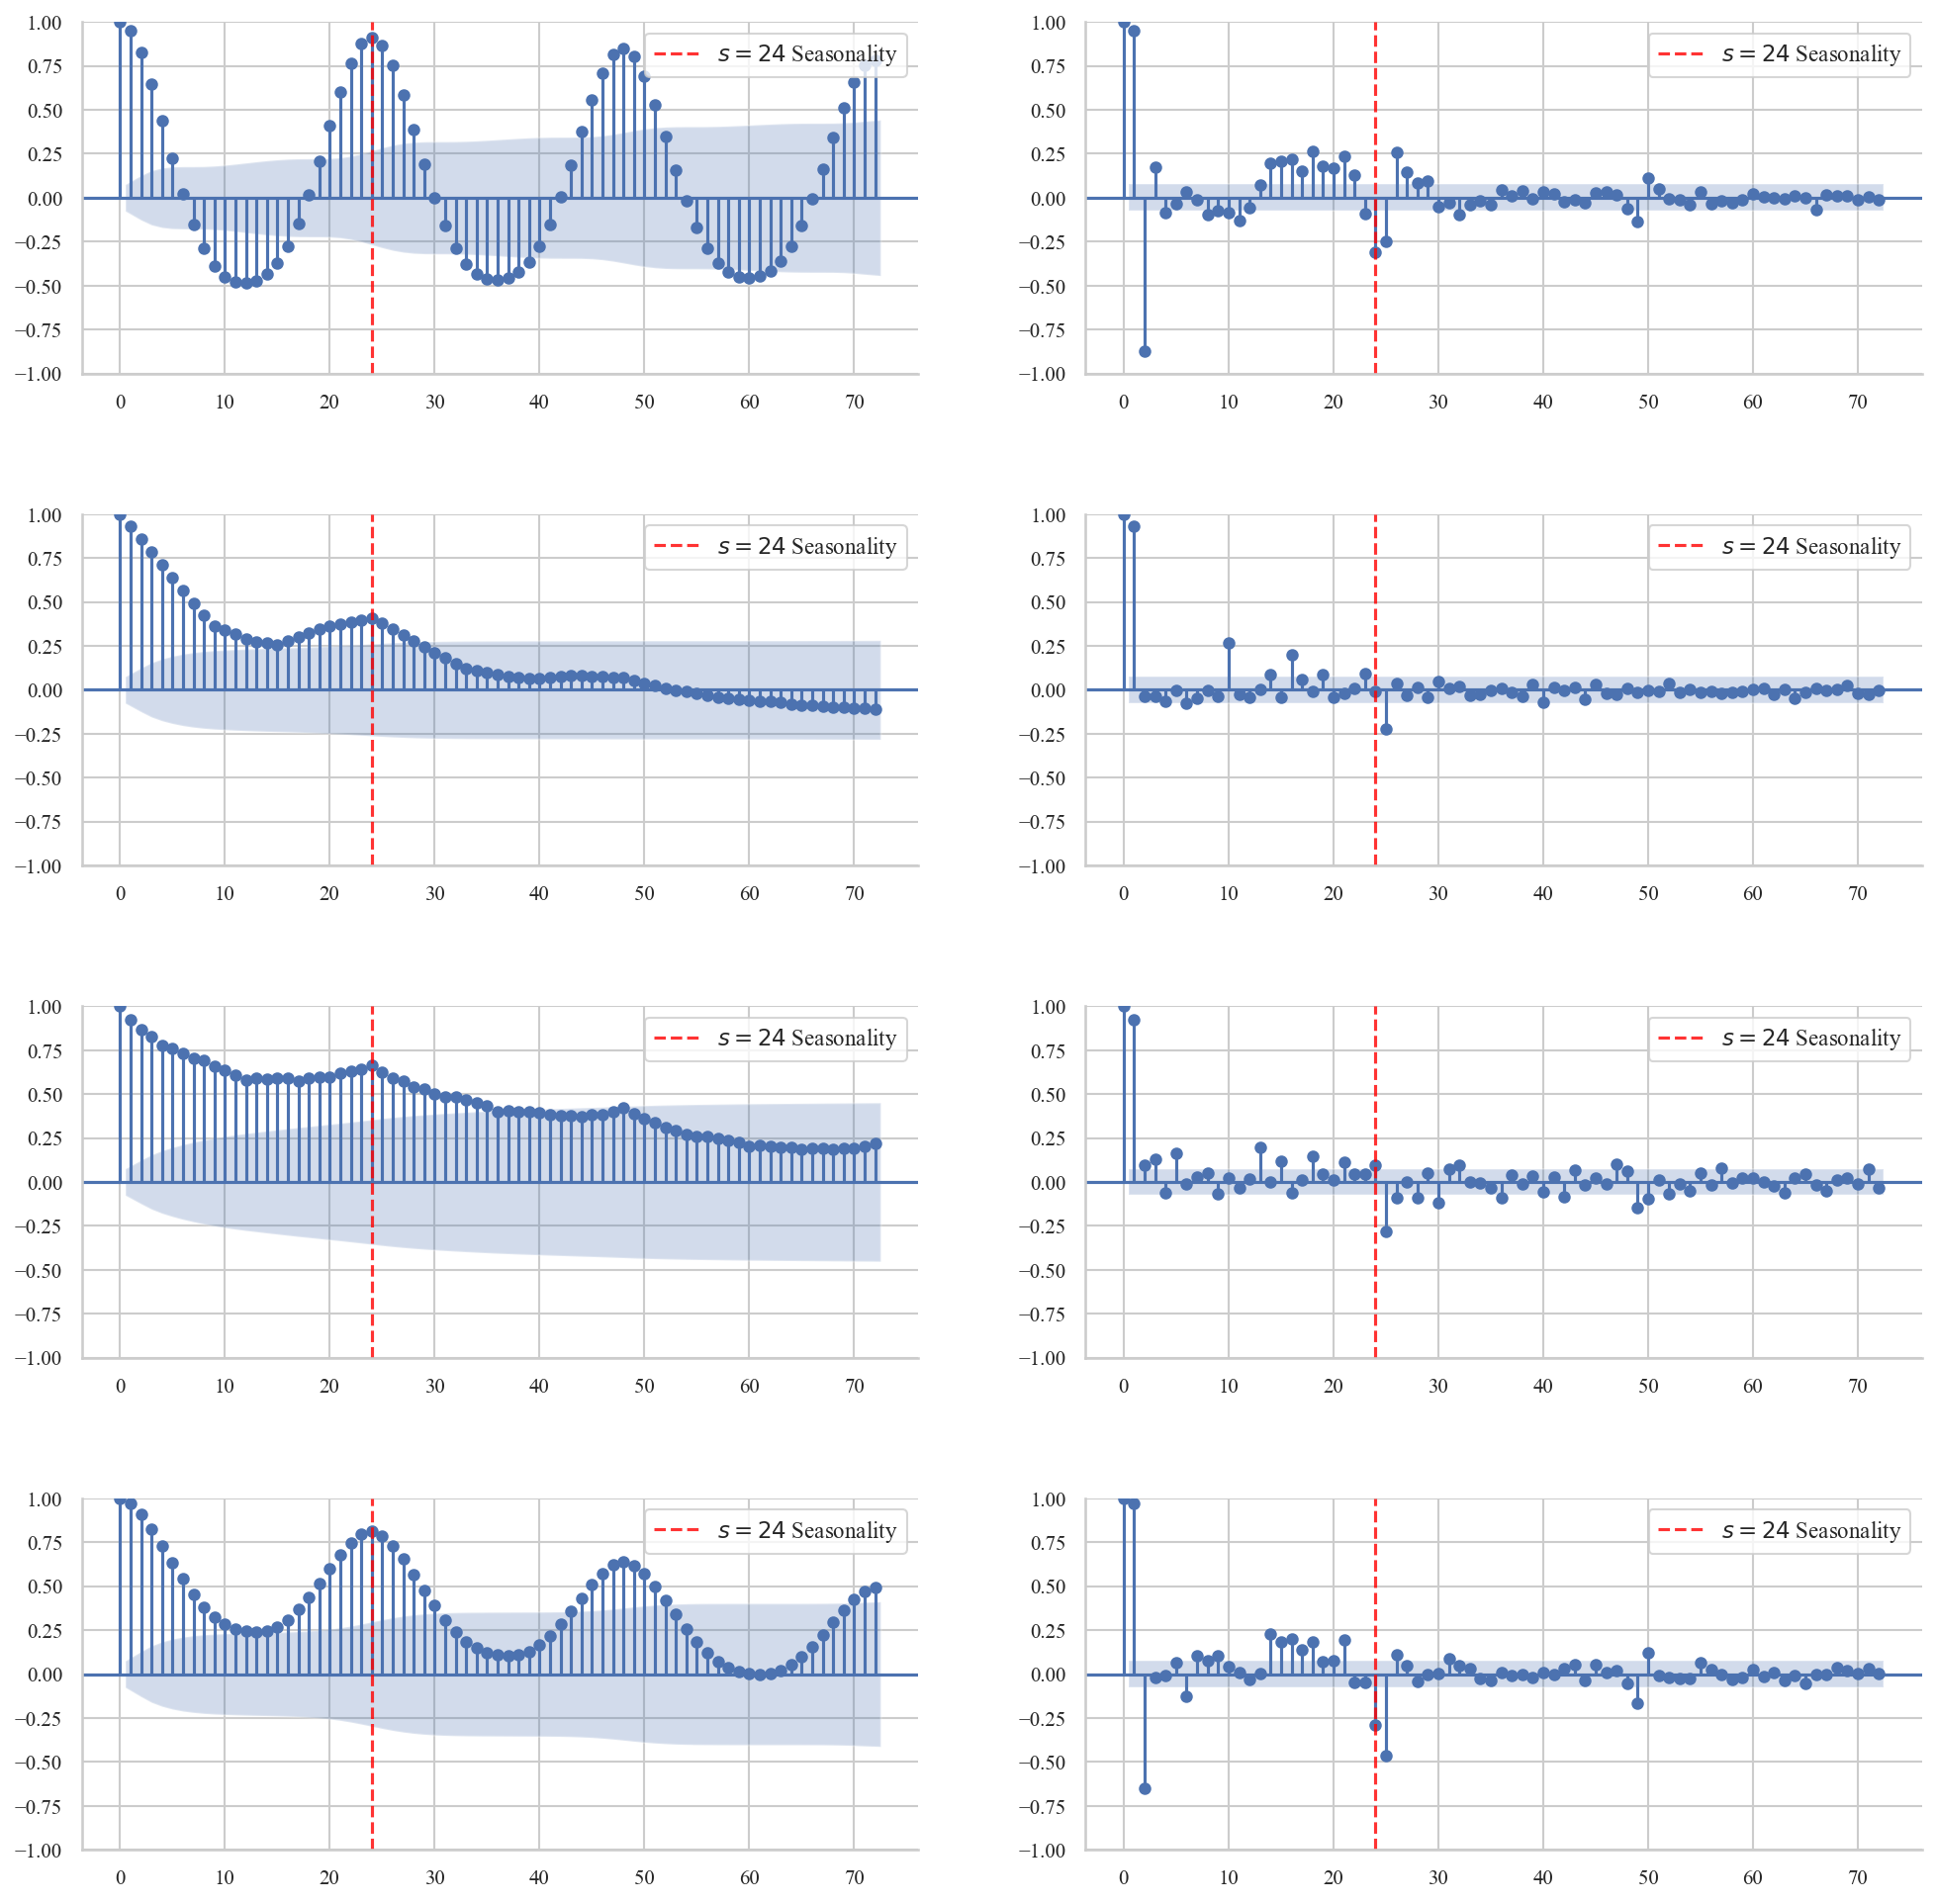


PHASE 3.2: HYPERPARAMETER OPTIMIZATION (GRID SEARCH RUNNING)

PHASE 3 COMPLETED IN 0.22 MINUTES.


In [4]:
# =============================================================================
# PHASE 3: PARAMETER JUSTIFICATION AND OPTIMIZATION (CACHED)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools
import warnings
import sys
import time
import os

warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join(RESULTS_BASE, "Phase_3")
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

CSV_PATH = os.path.join(OUTPUT_DIR, "Phase3_Optimal_Parameters.csv")
DIAG_PLOT_PATH = os.path.join(OUTPUT_DIR, "Phase3_Seasonality_Diagnostics.png")

# =============================================================================
# PART 1: SEASONALITY DIAGNOSTICS (ACF/PACF)
# =============================================================================

def perform_seasonality_diagnostics(df):
    """
    Generates ACF/PACF plots for seasonality validation.
    Titles are omitted from saved figures to meet academic standards.
    """
    print("\n" + "="*80)
    print("PHASE 3.1: SEASONALITY DIAGNOSTICS (ACF/PACF ANALYSIS)")
    print("="*80)

    try:
        # Representative weekly samples across seasons
        winter = df[(df.index >= '2022-01-10') & (df.index < '2022-01-17')]
        autumn = df[(df.index >= '2022-10-10') & (df.index < '2022-10-17')]
        spring = df[(df.index >= '2023-04-10') & (df.index < '2023-04-17')]
        summer = df[(df.index >= '2024-07-08') & (df.index < '2024-07-15')]

        subset = pd.concat([winter, autumn, spring, summer])
        print(f">> Representative subset created. Observations: {len(subset)}")
    except Exception as e:
        print(f"!! Sampling Error: {e}")
        return

    target_vars = ['Solar_Generation_Share', 'a-FRR_Price', 'Mcp', 'Consumption']
    fig, axes = plt.subplots(len(target_vars), 2, figsize=(16, 16))
    plt.subplots_adjust(hspace=0.4)

    print(f"{'VARIABLE':<30} | {'LAG-24 AUTOCORRELATION':<20}")
    print("-" * 60)

    for i, var in enumerate(target_vars):
        if var not in subset.columns: continue
        series = subset[var].dropna()

        plot_acf(series, lags=72, ax=axes[i, 0], title='')
        axes[i, 0].axvline(x=24, color='red', linestyle='--', alpha=0.8, label='$s=24$ Seasonality')
        axes[i, 0].legend(loc='upper right')

        plot_pacf(series, lags=72, ax=axes[i, 1], title='')
        axes[i, 1].axvline(x=24, color='red', linestyle='--', alpha=0.8, label='$s=24$ Seasonality')
        axes[i, 1].legend(loc='upper right')

        acf_vals = sm.tsa.acf(series, nlags=72)
        print(f"{var:<30} | {acf_vals[24]:.4f}")

    plt.savefig(DIAG_PLOT_PATH, dpi=FIG_DPI, bbox_inches='tight')
    print(f">> Diagnostic plots saved to '{DIAG_PLOT_PATH}'")
    plt.show()

# =============================================================================
# PART 2: GRID SEARCH OPTIMIZATION
# =============================================================================

def execute_grid_search_optimization(df):
    """
    Runs the SARIMAX grid search algorithm over the candidate parameter space.
    Results are saved to CSV_PATH upon completion.
    """
    print("\n" + "="*80)
    print("PHASE 3.2: HYPERPARAMETER OPTIMIZATION (GRID SEARCH RUNNING)")
    print("="*80)

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    target_df = locals().get('df', globals().get('df'))

    if target_df is not None:
        global_start = time.time()

        perform_seasonality_diagnostics(target_df)

        if os.path.exists(CSV_PATH):
            print("\n" + "="*80)
            print(f"PHASE 3.2: HYPERPARAMETER OPTIMIZATION (LOADED FROM '{OUTPUT_DIR}')")
            print("="*80)
            print(f">> Cached results found. Skipping computation...")

            results_df = pd.read_csv(CSV_PATH, index_col=0)

            print("\n" + "#" * 60)
            print("PHASE 3 RESULTS: OPTIMAL MODEL SPECIFICATIONS")
            print("#" * 60)

            for name, row in results_df.iterrows():
                report_str = (f"\nModel: {name}\n"
                              f"   Best Order (p,d,q)   : {row['Order']}\n"
                              f"   Best Seasonal (P,D,Q): {row['Seasonal']} (s=24)\n"
                              f"   AIC Score            : {row['AIC']:.4f}\n"
                              f"{'-' * 60}")
                print(report_str)
        else:
            execute_grid_search_optimization(target_df)

        duration = (time.time() - global_start) / 60
        print("\n" + "="*80)
        print(f"PHASE 3 COMPLETED IN {duration:.2f} MINUTES.")
        print("="*80)
    else:
        print("!! Critical Error: DataFrame 'df' not found. Please execute Phase 1.")

## Phase 4: Robust Estimation with Optimized Parameters

Re-estimates the core SARIMAX models using the optimal parameters identified in Phase 3. Saves full regression summaries, coefficient tables, and diagnostic metrics.

In [5]:
# =============================================================================
# PHASE 4: ROBUST ESTIMATION WITH OPTIMIZED PARAMETERS (CACHED)
# =============================================================================
import pandas as pd
import statsmodels.api as sm
import os

OUTPUT_DIR_P4 = os.path.join(RESULTS_BASE, "Phase_4")
os.makedirs(OUTPUT_DIR_P4, exist_ok=True)

REPORT_FILE_P4 = os.path.join(OUTPUT_DIR_P4, "Phase4_Full_Estimation_Report.txt")
COEF_FILE_P4 = os.path.join(OUTPUT_DIR_P4, "Phase4_All_Coefficients.csv")
DIAG_FILE_P4 = os.path.join(OUTPUT_DIR_P4, "Phase4_Model_Diagnostics.csv")

def run_phase_4(df):
    print("\n" + "="*80 + "\nPHASE 4: ROBUST ESTIMATION PROCESS STARTED\n" + "="*80)


    if os.path.exists(REPORT_FILE_P4) and os.path.exists(COEF_FILE_P4):
        print(f">> [CACHE] Results found in '{OUTPUT_DIR_P4}'. Skipping estimation.\n>> Loading cached report...\n" + "-" * 80)
        with open(REPORT_FILE_P4, "r", encoding="utf-8") as f:
            print(f.read())
        print("-" * 80 + f"\n>> Coefficients loaded from '{COEF_FILE_P4}'.")
        return

    print(">> No cached results found. Running SARIMAX estimation (est. 5-15 min)...")

    ORDER_MCP, SEASONAL_MCP = (2, 0, 2), (1, 0, 1, 24)
    ORDER_aFRR, SEASONAL_aFRR = (1, 1, 2), (1, 0, 1, 24)

    # Özellik mühendisliği (Eksikse tamamla)
    if 'Interaction_Solar_Sunday' not in df.columns:
        df['Sunday'] = (df.index.dayofweek == 6).astype(int)
        df['Interaction_Solar_Sunday'] = df['Solar_Generation_Share'] * df['Sunday']
        df['Interaction_Solar_Holiday'] = df['Solar_Generation_Share'] * df.get('Public_Holiday', 0)
        for h in range(8, 18):
            df[f'Solar_Share_x_Hour_{h}'] = df['Solar_Generation_Share'] * (df['Hour'] == h).astype(int)
        df['Interaction_Solar_Peak'] = df['Solar_Generation_Share'] * ((df['Hour'] >= 10) & (df['Hour'] <= 15)).astype(int)
        df['Interaction_Solar_Dir_Down'] = df['Solar_Generation_Share'] * df['System_Direction_Down']
        df['Interaction_Solar_Dir_Up'] = df['Solar_Generation_Share'] * df.get('System_Direction_Up', 0)

    common_controls = [
        'Consumption', 'Wind_Generation', 'Import_Coal_Generation', 
        'Hydroelectric_Generation', 'Domestic_Coal_Generation', 'Price_Cap', 
        'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos', 
        'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'
    ]
    hourly_cols = [c for c in df.columns if 'Solar_Share_x_Hour_' in c]

    models_config = [
        {'id': 'Model 1', 'name': 'a-FRR Baseline', 'y': 'a-FRR_Price', 'params': 'aFRR', 'X': common_controls + ['Solar_Generation_Share', 'Interaction_Solar_Sunday', 'Interaction_Solar_Holiday']},
        {'id': 'Model 2', 'name': 'a-FRR Hourly', 'y': 'a-FRR_Price', 'params': 'aFRR', 'X': common_controls + hourly_cols},
        {'id': 'Model 7.3', 'name': 'a-FRR Flexibility Trap', 'y': 'a-FRR_Price', 'params': 'aFRR', 'X': common_controls + ['Solar_Generation_Share', 'System_Direction_Down', 'System_Direction_Up', 'Interaction_Solar_Dir_Down', 'Interaction_Solar_Dir_Up']},
        {'id': 'Model 4', 'name': 'MCP Baseline', 'y': 'Mcp', 'params': 'MCP', 'X': common_controls + ['Solar_Generation_Share', 'Interaction_Solar_Sunday', 'Interaction_Solar_Holiday']},
        {'id': 'Model 5', 'name': 'MCP Hourly', 'y': 'Mcp', 'params': 'MCP', 'X': common_controls + hourly_cols}
    ]

    coefficient_frames, diagnostic_summary = [], []

    with open(REPORT_FILE_P4, "w", encoding="utf-8") as f:
        f.write("PHASE 4: FULL ESTIMATION RESULTS (OPTIMIZED PARAMETERS)\n" + "="*80 + "\n\n")
        
        for idx, config in enumerate(models_config, 1):
            print(f">> [{idx}/{len(models_config)}] Running {config['id']}: {config['name']}...")
            order, seasonal = (ORDER_MCP, SEASONAL_MCP) if config['params'] == 'MCP' else (ORDER_aFRR, SEASONAL_aFRR)

            # Eksik verileri filtrele
            data_mod = df[[config['y']] + config['X']].dropna()
            
            try:
                model = sm.tsa.SARIMAX(
                    endog=data_mod[config['y']], 
                    exog=data_mod[config['X']], 
                    order=order, 
                    seasonal_order=seasonal, 
                    enforce_stationarity=False, 
                    enforce_invertibility=False
                )
                res = model.fit(disp=False)

                f.write(f"\n{'#'*90}\nRESULTS FOR {config['id']}: {config['name']}\n{'#'*90}\n{res.summary()}\n")
                print("-" * 90 + f"\nRESULTS SUMMARY FOR {config['id']}\n" + "-" * 90)
                print(res.summary().tables[1])

                coef_df = res.params.to_frame(name='Coefficient')
                coef_df['Model_ID'] = config['id']
                coefficient_frames.append(coef_df)
                diagnostic_summary.append({'Model_ID': config['id'], 'AIC': res.aic, 'BIC': res.bic})
            except Exception as e:
                print(f"   !!! ERROR in {config['id']}: {e}")

    if coefficient_frames:
        pd.concat(coefficient_frames).to_csv(COEF_FILE_P4)
        pd.DataFrame(diagnostic_summary).to_csv(DIAG_FILE_P4, index=False)
    print(f"\n{'='*80}\nPHASE 4 COMPLETED. Outputs saved to '{OUTPUT_DIR_P4}'.")

# Çalıştırma
if 'df' in globals() and df is not None:
    run_phase_4(df)


PHASE 4: ROBUST ESTIMATION PROCESS STARTED
>> [CACHE] Results found in '..\results\Phase_4'. Skipping estimation.
>> Loading cached report...
--------------------------------------------------------------------------------
PHASE 4: FULL ESTIMATION RESULTS (OPTIMIZED PARAMETERS)


##########################################################################################
RESULTS FOR Model 1: a-FRR Baseline
##########################################################################################
                                      SARIMAX Results                                       
Dep. Variable:                          a-FRR_Price   No. Observations:                35064
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 24)   Log Likelihood             -259382.169
Date:                              Tue, 24 Feb 2026   AIC                         518814.337
Time:                                      05:32:56   BIC                         519025.941
Sample:                            

## Phase 5: Advanced Visualization (SARIMAX Results)


>> Phase 5: Generating dynamic publication-ready figures to '..\results\Phase_5'...


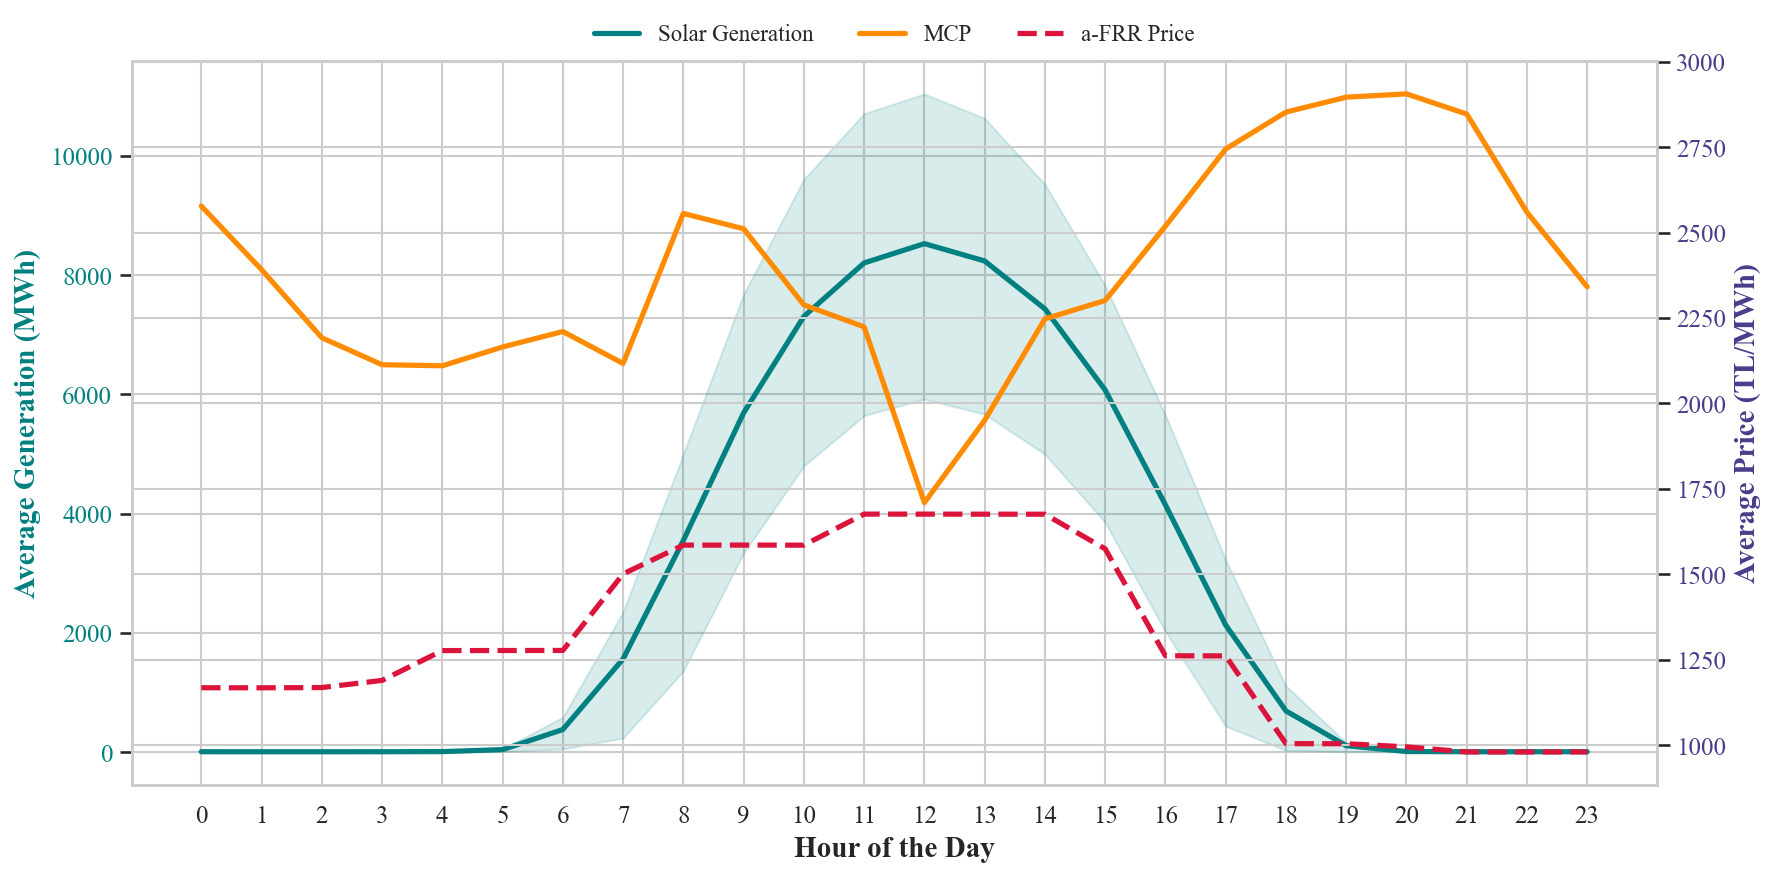

>> Generating 2025 subset profile...


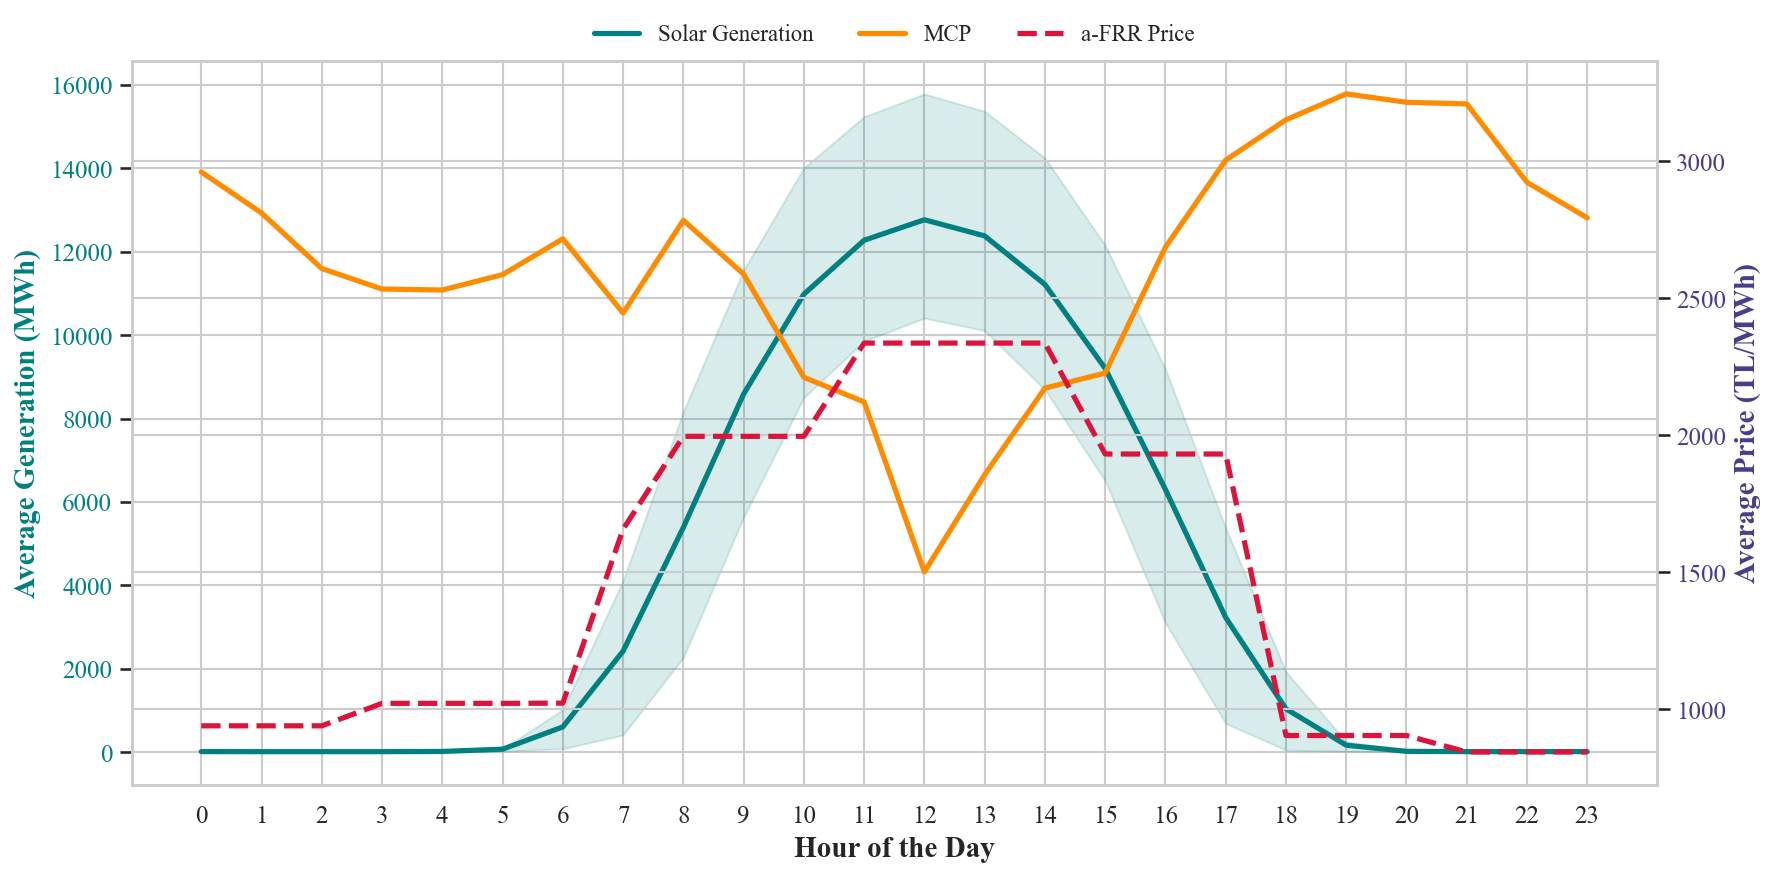

>> Extracting dynamic coefficients from ..\results\Phase_4\Phase4_All_Coefficients.csv...


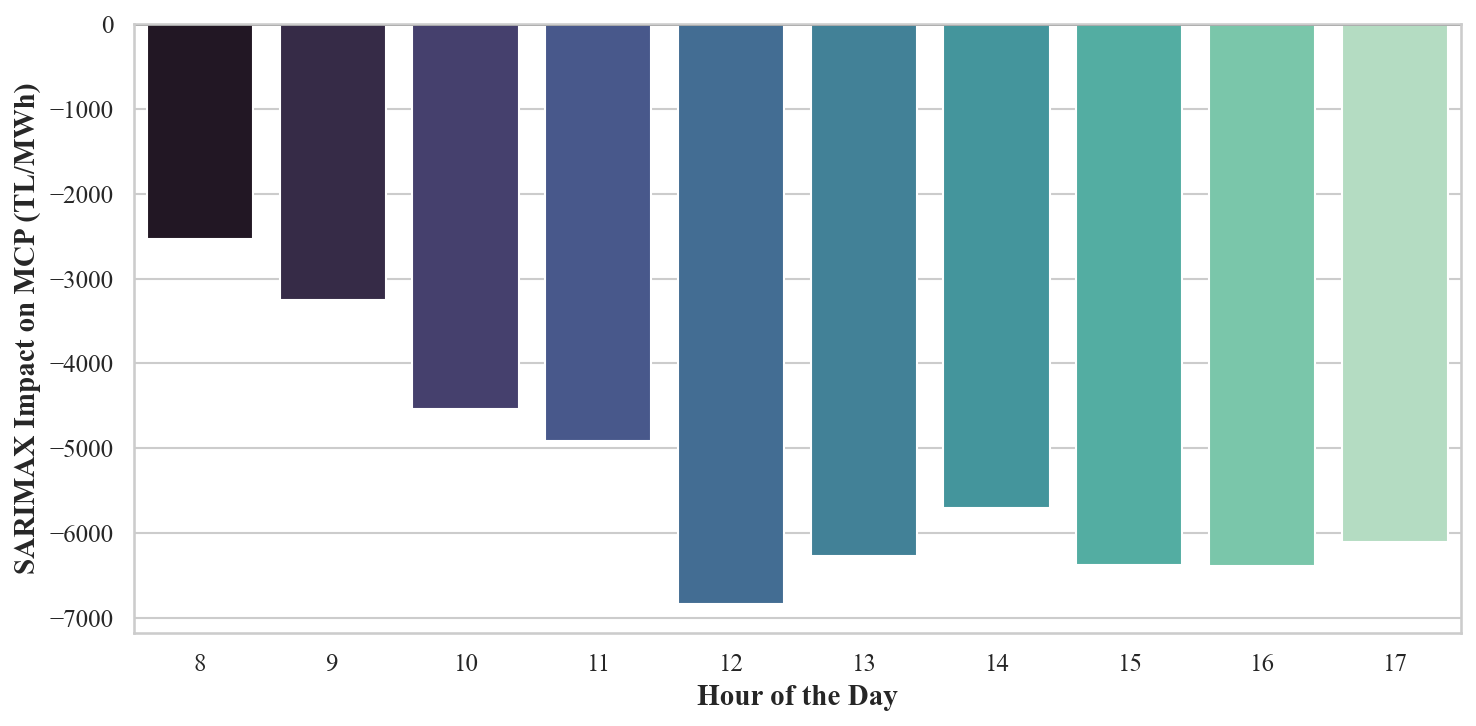

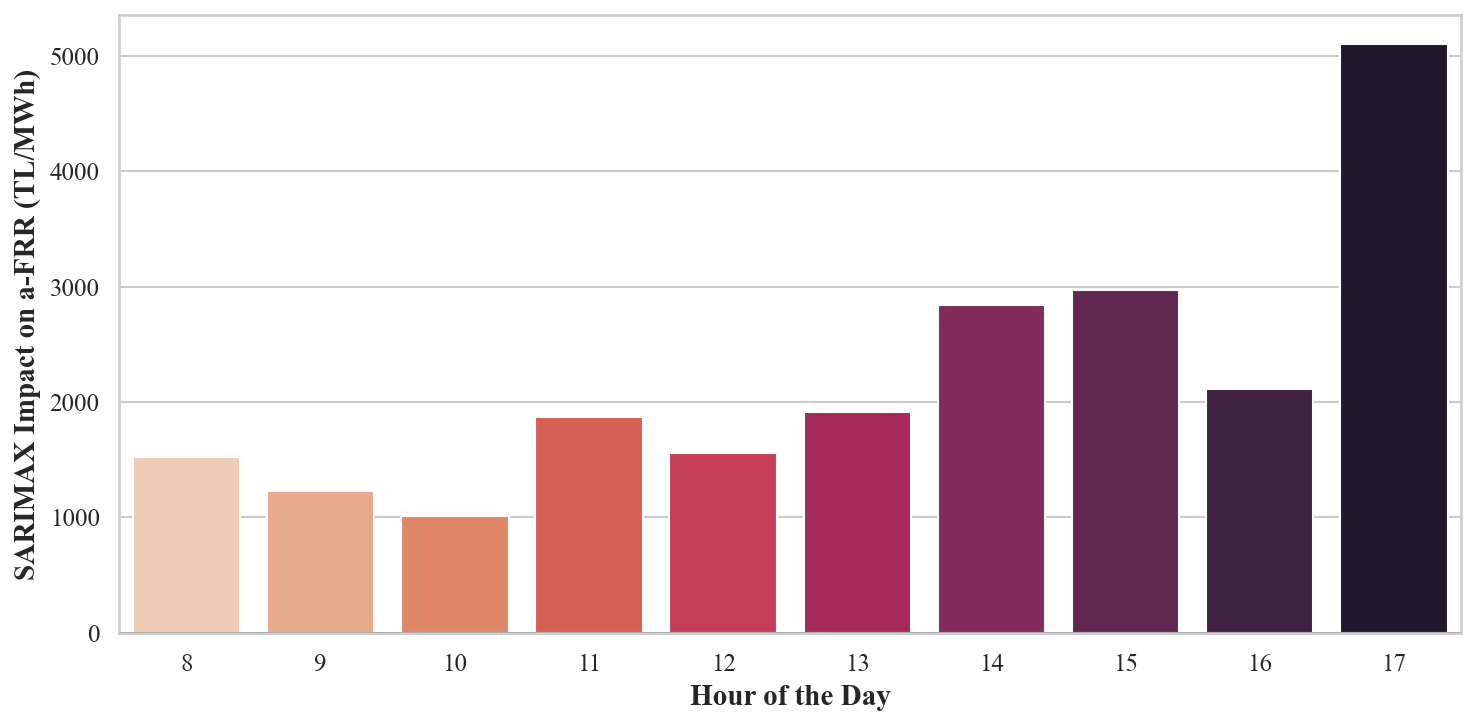


>> Phase 5 completed dynamically. Outputs saved to '..\results\Phase_5'.


In [6]:
# =============================================================================
# PHASE 5: ADVANCED VISUALIZATION (SARIMAX) - FULLY DYNAMIC EXPORT MODE
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

# Output directory configuration
if os.path.isdir("results"):
    RESULTS_BASE = "results"
elif os.path.isdir(os.path.join("..", "results")):
    RESULTS_BASE = os.path.join("..", "results")
else:
    RESULTS_BASE = "results"

OUTPUT_DIR_P5 = os.path.join(RESULTS_BASE, "Phase_5")
COEF_FILE_P4 = os.path.join(RESULTS_BASE, "Phase_4", "Phase4_All_Coefficients.csv")
os.makedirs(OUTPUT_DIR_P5, exist_ok=True)

# Academic visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

def get_dynamic_coefficients(csv_path: str, model_id: str) -> dict:
    """
    Reads hourly Solar_Share_x_Hour coefficients from the Phase 4 CSV output 
    for a given model and returns them as a dictionary.
    
    Args:
        csv_path (str): Path to the Phase 4 coefficient file.
        model_id (str): Model ID to extract (e.g. 'Model 2', 'Model 5').
        
    Returns:
        dict: {hour (int): coefficient (float)} dictionary.
    """
    coeffs = {}
    try:
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Coefficient file not found: {csv_path}")
            
        df_coef = pd.read_csv(csv_path, index_col=0)
        
        # Filter coefficients for the target model
        model_data = df_coef[df_coef['Model_ID'] == model_id]
        
        if model_data.empty:
            raise ValueError(f"Model '{model_id}' not found in coefficient file.")
            
        # Extract hourly coefficients from hour 8 to 17
        for h in range(8, 18):
            col_name = f'Solar_Share_x_Hour_{h}'
            if col_name in model_data.index:
                val = model_data.loc[col_name, 'Coefficient']
                # Take first value if multiple matches (duplicate index guard)
                if isinstance(val, pd.Series):
                    val = val.iloc[0]
                coeffs[h] = float(val)
                
    except Exception as e:
        print(f"!! COEFFICIENT READ ERROR ({model_id}): {e}")
        
    return coeffs

def run_phase_5_final(df: pd.DataFrame):
    """
    Visualizes market profiles and SARIMAX coefficients.
    Dynamically reads coefficients from Phase 4 outputs instead of hardcoding.
    """
    print(f">> Phase 5: Generating dynamic publication-ready figures to '{OUTPUT_DIR_P5}'...")

    # Datetime index safety check
    if 'Date' in df.columns and not np.issubdtype(df['Date'].dtype, np.datetime64):
        df['Date'] = pd.to_datetime(df['Date'])
    elif isinstance(df.index, pd.DatetimeIndex):
        df['Date'] = df.index

    # =========================================================================
    # FIGURE 1 & 2: DAILY MARKET PROFILE
    # =========================================================================
    h_sum = df.groupby('Hour').agg(
        M_Sol=('Solar_Generation', 'mean'),
        Q25=('Solar_Generation', lambda x: x.quantile(0.25)),
        Q75=('Solar_Generation', lambda x: x.quantile(0.75)),
        M_MCP=('Mcp', 'mean'),
        M_aFRR=('a-FRR_Price', 'mean')
    ).reset_index()

    def plot_profile(data, title, filename):
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.set_xlabel('Hour of the Day', fontweight='bold')
        ax1.set_ylabel('Average Generation (MWh)', color='teal', fontweight='bold')
        ax1.plot(data['Hour'], data['M_Sol'], color='teal', linewidth=2.5, label='Solar Generation')
        ax1.fill_between(data['Hour'], data['Q25'], data['Q75'], color='teal', alpha=0.15)
        ax1.tick_params(axis='y', labelcolor='teal')

        ax2 = ax1.twinx()
        ax2.set_ylabel('Average Price (TL/MWh)', color='darkslateblue', fontweight='bold')
        ax2.plot(data['Hour'], data['M_MCP'], color='darkorange', linewidth=2.5, label='MCP')
        ax2.plot(data['Hour'], data['M_aFRR'], color='crimson', linestyle='--', linewidth=2.5, label='a-FRR Price')
        ax2.tick_params(axis='y', labelcolor='darkslateblue')

        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(.5, 1.08), ncol=3, frameon=False)

        plt.xticks(np.arange(0, 24, 1))
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR_P5, filename), dpi=FIG_DPI, bbox_inches='tight')
        plt.show()

    plot_profile(h_sum, "Full Dataset", 'Phase_5_Figure_1_Daily_Market_Profile.png')

    if 'Date' in df.columns:
        print(">> Generating 2025 subset profile...")
        df_2025 = df[df['Date'].dt.year == 2025].copy()
        if not df_2025.empty:
            h_sum_25 = df_2025.groupby('Hour').agg(
                M_Sol=('Solar_Generation', 'mean'),
                Q25=('Solar_Generation', lambda x: x.quantile(0.25)),
                Q75=('Solar_Generation', lambda x: x.quantile(0.75)),
                M_MCP=('Mcp', 'mean'),
                M_aFRR=('a-FRR_Price', 'mean')
            ).reset_index()
            plot_profile(h_sum_25, "2025", 'Phase_5_Figure_2_Daily_Market_Profile.png')

    # =========================================================================
    # FIGURE 4 & 6: DYNAMIC SARIMAX HOURLY IMPACT COEFFICIENTS
    # =========================================================================
    print(f">> Extracting dynamic coefficients from {COEF_FILE_P4}...")
    
    # Dynamic coefficient extraction for Model 5 (MCP) and Model 2 (a-FRR)
    ptf_coeffs = get_dynamic_coefficients(COEF_FILE_P4, 'Model 5')
    sfk_coeffs = get_dynamic_coefficients(COEF_FILE_P4, 'Model 2')

    configs = []
    if ptf_coeffs:
        configs.append((ptf_coeffs, 'Phase_5_Figure_4_Hourly_Merit_Order_Effect_MCP.png', 'mako', 'SARIMAX Impact on MCP (TL/MWh)'))
    if sfk_coeffs:
        configs.append((sfk_coeffs, 'Phase_5_Figure_6_Hourly_Volatility_Effect_aFRR.png', 'rocket_r', 'SARIMAX Impact on a-FRR (TL/MWh)'))

    if not configs:
        print("!! WARNING: Could not read dynamic coefficients. Bar plots skipped.")
    else:
        for coeffs, filename, pal, y_label in configs:
            plt.figure(figsize=(10, 5))
            ser = pd.Series(coeffs)
            sns.barplot(x=ser.index, y=ser.values, palette=pal)
            
            plt.axhline(0, color='black', linewidth=1.2)
            plt.xlabel('Hour of the Day', fontweight='bold')
            plt.ylabel(y_label, fontweight='bold')
            plt.tight_layout()

            plt.savefig(os.path.join(OUTPUT_DIR_P5, filename), dpi=FIG_DPI, bbox_inches='tight')
            plt.show()

    print(f"\n>> Phase 5 completed dynamically. Outputs saved to '{OUTPUT_DIR_P5}'.")

# --- Execution ---
if __name__ == "__main__":
    target_df = locals().get('df', globals().get('df'))
    if target_df is not None:
        run_phase_5_final(target_df)
    else:
        print("!! ERROR: DataFrame 'df' not found in memory. Please execute Phase 1 first.")

### Phase 6.1: Partial Dependence Analysis


PHASE 6.1: ML Analysis (Directory: '..\results\Phase_6')...
>> [CACHE] Existing analyses found in '..\results\Phase_6'.
>> Skipping XGBoost training, loading saved plots...



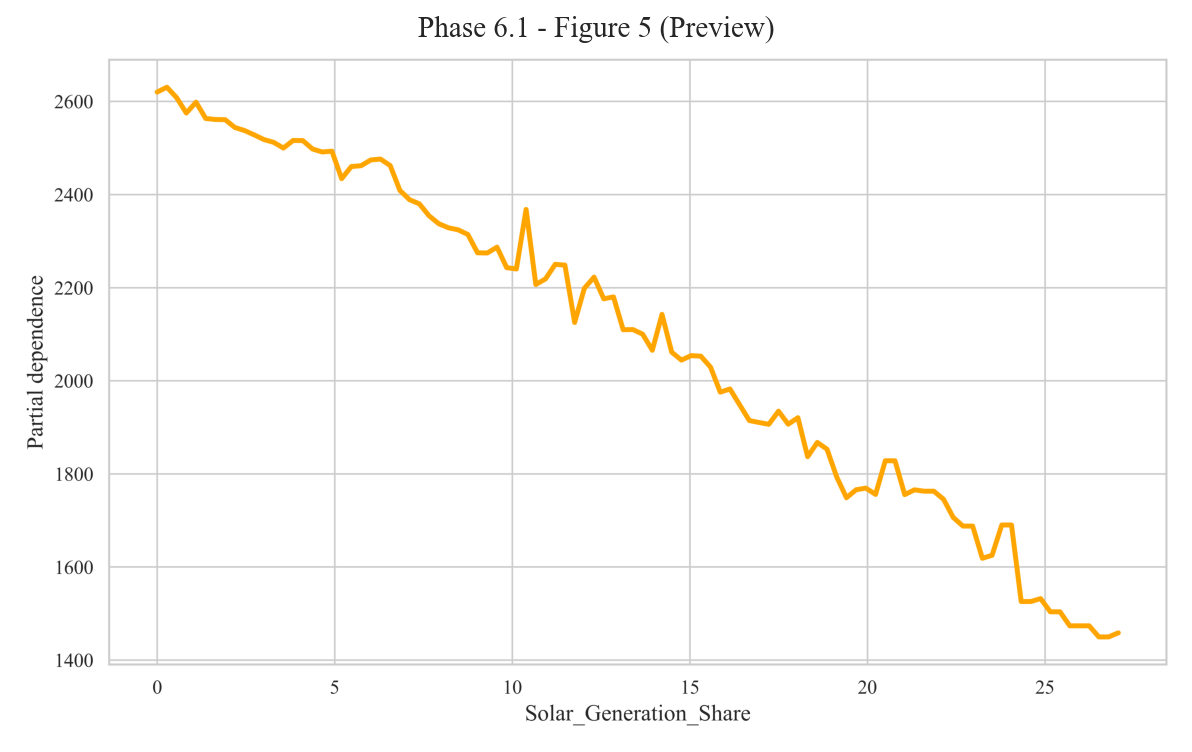

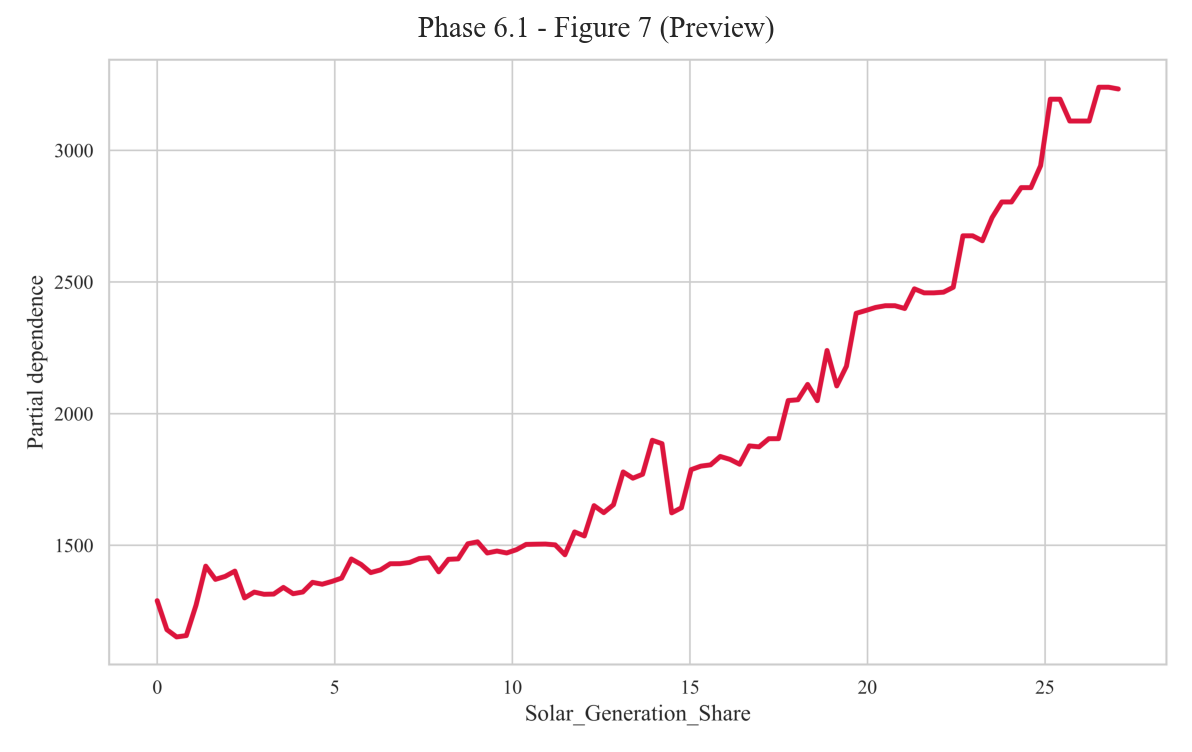

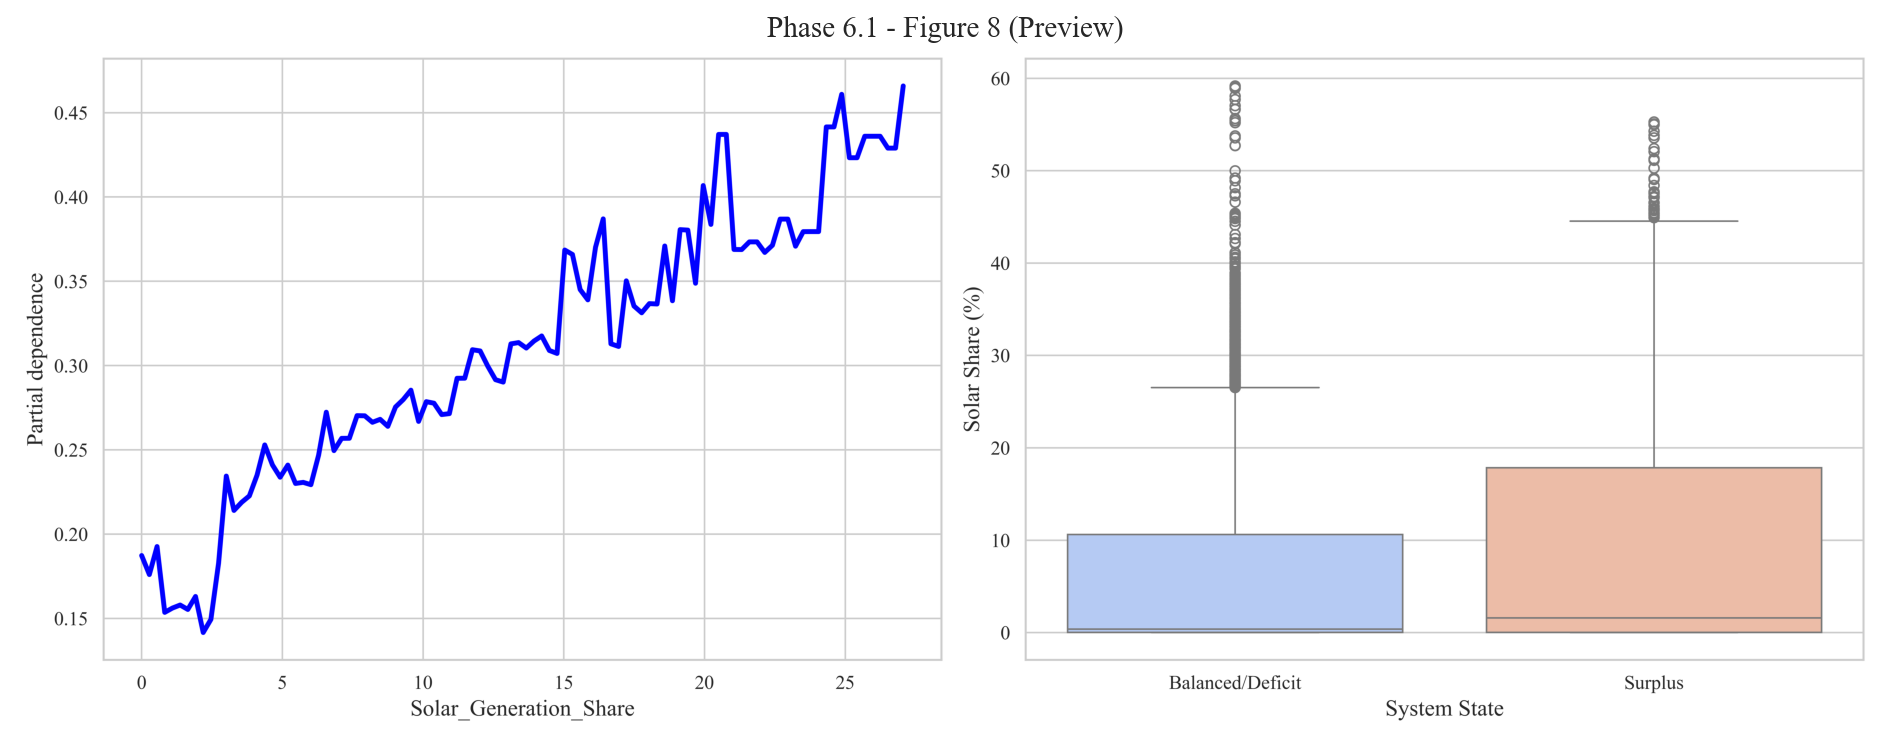

>> Cached data from '..\results\Phase_6' loaded successfully.
>> To regenerate, delete the PNG files and re-run this cell.


In [7]:
# =================================================================================================
# PHASE 6.1: NON-LINEAR IMPACT ANALYSIS (XGBOOST) - REVISED (DECILE LINES REMOVED)
# =================================================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.inspection import PartialDependenceDisplay
import os
import warnings

warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join(RESULTS_BASE, "Phase_6")
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

def check_phase6_plots():
    """Checks if the required individual plot files already exist."""
    fig_5 = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_5_PDP_Merit_Order_and_Volatility.png')
    fig_7 = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_7_PDP_Merit_Order_and_Volatility.png')
    fig_8 = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_8_Surplus_Probability_and_Distribution.png')
    return os.path.exists(fig_5) and os.path.exists(fig_7) and os.path.exists(fig_8)

def run_phase_6_1_final(df):
    print(f"PHASE 6.1: ML Analysis (Directory: '{OUTPUT_DIR}')...")
    print("="*80)

    if check_phase6_plots():
        print(f">> [CACHE] Existing analyses found in '{OUTPUT_DIR}'.")
        print(">> Skipping XGBoost training, loading saved plots...\n")

        fig_5_path = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_5_PDP_Merit_Order_and_Volatility.png')
        fig_7_path = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_7_PDP_Merit_Order_and_Volatility.png')
        fig_8_path = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_8_Surplus_Probability_and_Distribution.png')

        plt.figure(figsize=(10, 6)); plt.imshow(plt.imread(fig_5_path)); plt.axis('off')
        plt.title("Phase 6.1 - Figure 5 (Preview)", fontsize=14); plt.show()

        plt.figure(figsize=(10, 6)); plt.imshow(plt.imread(fig_7_path)); plt.axis('off')
        plt.title("Phase 6.1 - Figure 7 (Preview)", fontsize=14); plt.show()

        plt.figure(figsize=(16, 6)); plt.imshow(plt.imread(fig_8_path)); plt.axis('off')
        plt.title("Phase 6.1 - Figure 8 (Preview)", fontsize=14); plt.show()

        print(f">> Cached data from '{OUTPUT_DIR}' loaded successfully.")
        print(">> To regenerate, delete the PNG files and re-run this cell.")
        return

    print(">> No cached results found. Training XGBoost models...")

    df_ml = df.copy()
    if df_ml['Solar_Generation_Share'].max() <= 1.0:
        df_ml['Solar_Generation_Share'] *= 100

    features_core = ['Solar_Generation_Share', 'Consumption', 'Wind_Generation', 'Price_Cap', 'Hour_Sin', 'Hour_Cos']
    features_with_mcp = features_core + ['Mcp']

    m_a = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(df_ml[features_core], df_ml['Mcp'])
    m_b = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(df_ml[features_with_mcp], df_ml['a-FRR_Price'])
    m_c = xgb.XGBClassifier(n_estimators=200, random_state=42).fit(df_ml[features_core], df_ml['System_Direction_Down'])

    # FIGURE 5: MCP MERIT ORDER EFFECT
    print(">> Plotting Figure 5 (MCP)...")
    fig5, ax5 = plt.subplots(figsize=(10, 6))
    disp5 = PartialDependenceDisplay.from_estimator(
        m_a, df_ml[features_core], ['Solar_Generation_Share'],
        ax=ax5, line_kw={"color": "orange", "linewidth": 3}
    )
    # Remove decile markers for cleaner output
    for vlines in disp5.deciles_vlines_:
        for v in vlines:
            v.set_visible(False)
    ax5.set_xlabel('Solar Share (%)')
    ax5.set_ylabel('Partial Dependence (MCP)')
    plt.tight_layout()
    save_path_fig5 = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_5_PDP_Merit_Order_and_Volatility.png')
    plt.savefig(save_path_fig5, dpi=FIG_DPI, bbox_inches='tight')
    plt.title("Phase 6.1 - Figure 5: MCP Merit-Order Effect (Preview Only)", fontsize=14)
    plt.show()

    # FIGURE 7: a-FRR VOLATILITY EFFECT
    print(">> Plotting Figure 7 (a-FRR)...")
    fig7, ax7 = plt.subplots(figsize=(10, 6))
    disp7 = PartialDependenceDisplay.from_estimator(
        m_b, df_ml[features_with_mcp], ['Solar_Generation_Share'],
        ax=ax7, line_kw={"color": "crimson", "linewidth": 3}
    )
    for vlines in disp7.deciles_vlines_:
        for v in vlines:
            v.set_visible(False)
    ax7.set_xlabel('Solar Share (%)')
    ax7.set_ylabel('Partial Dependence (a-FRR)')
    plt.tight_layout()
    save_path_fig7 = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_7_PDP_Merit_Order_and_Volatility.png')
    plt.savefig(save_path_fig7, dpi=FIG_DPI, bbox_inches='tight')
    plt.title("Phase 6.1 - Figure 7: a-FRR Volatility Effect (Preview Only)", fontsize=14)
    plt.show()

    # FIGURE 8: SURPLUS ANALYSIS
    print(">> Plotting Figure 8 (Surplus Analysis)...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    disp8 = PartialDependenceDisplay.from_estimator(
        m_c, df_ml[features_core], ['Solar_Generation_Share'],
        ax=ax1, line_kw={"color": "blue", "linewidth": 3}
    )
    for vlines in disp8.deciles_vlines_:
        for v in vlines:
            v.set_visible(False)
    ax1.set_xlabel('Solar Share (%)')
    ax1.set_ylabel('Probability of Energy Surplus')

    sns.boxplot(x=df_ml['System_Direction_Down'], y=df_ml['Solar_Generation_Share'], palette="coolwarm", ax=ax2)
    ax2.set_xticklabels(['Balanced/Deficit', 'Surplus'])
    ax2.set_xlabel('System State')
    ax2.set_ylabel('Solar Share (%)')
    plt.tight_layout()
    save_path_surplus = os.path.join(OUTPUT_DIR, 'Phase_6_Figure_8_Surplus_Probability_and_Distribution.png')
    plt.savefig(save_path_surplus, dpi=FIG_DPI, bbox_inches='tight')
    plt.suptitle("Phase 6.1 - Figure 8: Surplus Analysis (Preview Only)", fontsize=16)
    plt.show()

    print(f"\n>> All ML analyses and figures saved to '{OUTPUT_DIR}'.")

if __name__ == "__main__":
    if 'df' in locals():
        run_phase_6_1_final(df)
    elif 'df' in globals():
        run_phase_6_1_final(globals()['df'])

### Phase 6.2: Flexibility Trap Analysis


>> Phase 6.2: Flexibility Trap Analysis (Directory: '..\results\Phase_6')...
>> [CACHE] Existing analysis found in '..\results\Phase_6'.
>> Skipping XGBoost training, loading saved plot...



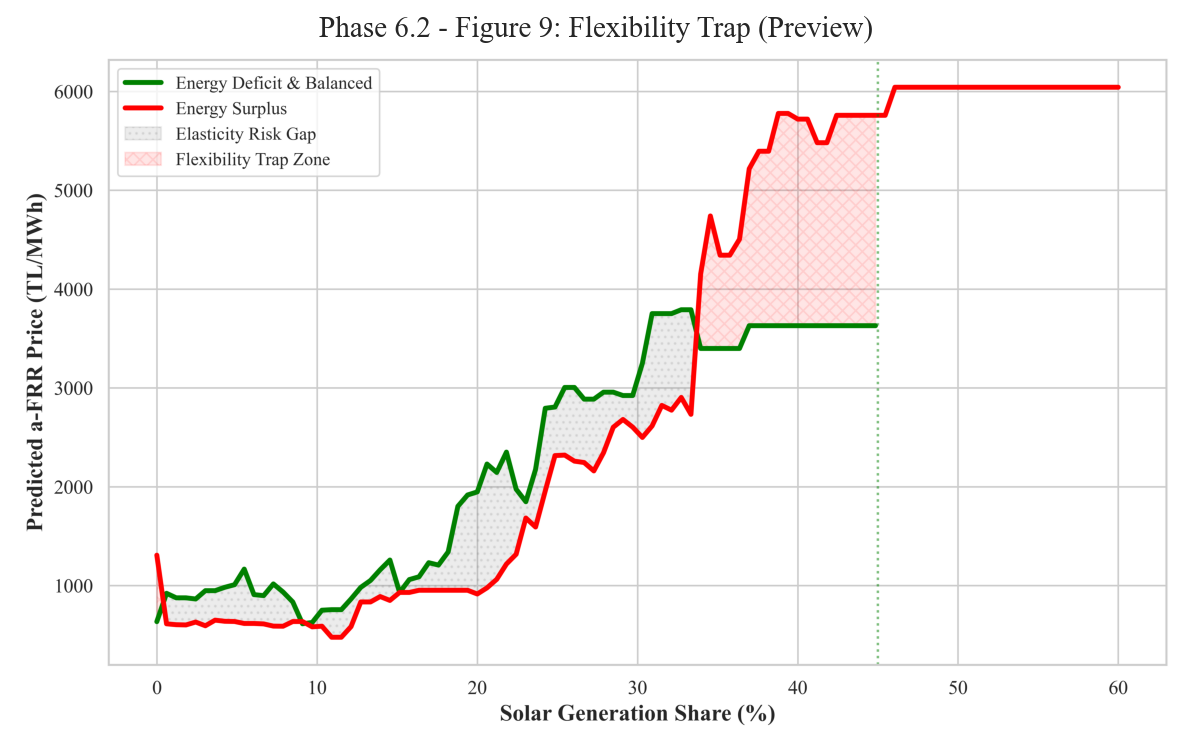

>> Cached data from '..\results\Phase_6' loaded successfully.
>> To regenerate, delete the PNG file and re-run this cell.


In [8]:
# =============================================================================
# PHASE 6.2: NON-LINEAR IMPACT ANALYSIS (XGBOOST) - FLEXIBILITY TRAP
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import warnings

warnings.filterwarnings("ignore")

OUTPUT_DIR_P6 = os.path.join(RESULTS_BASE, "Phase_6")
if not os.path.exists(OUTPUT_DIR_P6):
    os.makedirs(OUTPUT_DIR_P6)

# Academic plot settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

def check_phase6_2_plot():
    """Checks if Figure 9 (Flexibility Trap) already exists."""
    fig_9 = os.path.join(OUTPUT_DIR_P6, 'Phase_6_Figure_9_Flexibility_Trap.png')
    return os.path.exists(fig_9)

def run_phase_6_2_final(df):
    print(f">> Phase 6.2: Flexibility Trap Analysis (Directory: '{OUTPUT_DIR_P6}')...")
    print("="*80)

    fig_9_path = os.path.join(OUTPUT_DIR_P6, 'Phase_6_Figure_9_Flexibility_Trap.png')

    # Cache check
    if check_phase6_2_plot():
        print(f">> [CACHE] Existing analysis found in '{OUTPUT_DIR_P6}'.")
        print(">> Skipping XGBoost training, loading saved plot...\n")

        plt.figure(figsize=(10, 6))
        plt.imshow(plt.imread(fig_9_path))
        plt.axis('off')
        plt.title("Phase 6.2 - Figure 9: Flexibility Trap (Preview)", fontsize=14)
        plt.show()

        print(f">> Cached data from '{OUTPUT_DIR_P6}' loaded successfully.")
        print(">> To regenerate, delete the PNG file and re-run this cell.")
        return

    print(">> No cached results found. Training XGBoost models (Flexibility Trap)...")

    # Data preparation
    dm = df.copy()
    if dm['Solar_Generation_Share'].max() <= 1:
        dm['Solar_Generation_Share'] *= 100

    sur = dm[dm['System_Direction_Down'] == 1]
    dfc = dm[dm['System_Direction_Down'] == 0]

    ft = ['Solar_Generation_Share', 'Mcp', 'Consumption', 'Wind_Generation', 'Hour_Sin', 'Hour_Cos']

    # Model training
    print(">> Training conditional XGBoost models...")
    ms = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(sur[ft], sur['a-FRR_Price'])
    md = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(dfc[ft], dfc['a-FRR_Price'])

    # Ceteris paribus simulation
    sr = np.linspace(0, 60, 100)
    avg = dm[ft].median()
    sim = pd.DataFrame([avg]*100, columns=ft)
    sim['Solar_Generation_Share'] = sr

    mk = sr <= 45
    yd = md.predict(sim[mk][ft])
    ys = ms.predict(sim[ft])
    ysc = ys[:len(yd)]
    sc = sr[mk]

    # -------------------------------------------------------------------------
    # FIGURE 9: FLEXIBILITY TRAP
    # -------------------------------------------------------------------------
    print("  [Fig 9] Plotting Flexibility Trap...")
    fig, ax = plt.subplots(figsize=(10, 6))


    ax.plot(sc, yd, color='green', lw=3.0, label='Energy Deficit & Balanced')
    ax.plot(sr, ys, color='red', lw=3.0, label='Energy Surplus')
    
    # Zone 1: Elasticity Risk Gap
    ax.fill_between(
        sc, ysc, yd, 
        where=(yd >= ysc), interpolate=True, 
        color='gray', alpha=.15, hatch='...', 
        label='Elasticity Risk Gap'
    )
    
    # Zone 2: Flexibility Trap Zone
    ax.fill_between(
        sc, ysc, yd, 
        where=(ysc > yd), interpolate=True, 
        color='red', alpha=.10, hatch='xxx', 
        label='Flexibility Trap Zone'
    )

    ax.set_xlabel('Solar Generation Share (%)', fontweight='bold')
    ax.set_ylabel('Predicted a-FRR Price (TL/MWh)', fontweight='bold')
    ax.legend(loc='upper left', fontsize=11, frameon=True)
    ax.axvline(x=45, color='green', ls=':', alpha=.5)

    plt.tight_layout()
    plt.savefig(fig_9_path, dpi=FIG_DPI, bbox_inches='tight')
    plt.show()

    # Zone dominance statistics
    trap_pct = (ysc > yd).sum() / len(yd) * 100
    gap_pct = (yd >= ysc).sum() / len(yd) * 100
    print(f"\n>> Zone dominance in the 0-45% solar range:")
    print(f"   - Elasticity Risk Gap (Deficit > Surplus): {gap_pct:.1f}%")
    print(f"   - Flexibility Trap Zone (Surplus > Deficit): {trap_pct:.1f}%")

    print(f"\n>> Phase 6.2 complete. Flexibility Trap figure saved to '{OUTPUT_DIR_P6}'.")

# === MAIN EXECUTION ===
if __name__ == "__main__":
    if 'df' in globals() and df is not None:
        run_phase_6_2_final(df)
    else:
        print("ERROR: DataFrame 'df' not found. Please run Phase 1 first.")

## Phase 7: Robustness Checks (Quantile Regression)


PHASE 7: Robustness Checks (Quantile Regression) Process Started...
>> [CACHE] Results found in '..\results\Phase_7'. Loading...

PHASE 7: QUANTILE REGRESSION ROBUSTNESS REPORT

>>> HYPOTHESIS 1: MERIT-ORDER EFFECT ON MCP (ROBUSTNESS CHECK)
---------------------------------------------------------------------------
Quantile   | Coef (Solar)    | P-Value    | Status
---------------------------------------------------------------------------
Q10       | -3980.0145      | 0.0000     | CONFIRMED (-)
Q50       | -5421.3302      | 0.0000     | CONFIRMED (-)
Q90       | -2716.1559      | 0.0000     | CONFIRMED (-)

>>> HYPOTHESIS 2: VOLATILITY EFFECT ON a-FRR (ROBUSTNESS CHECK)
---------------------------------------------------------------------------
Quantile   | Coef (Solar)    | P-Value    | Interpretation
---------------------------------------------------------------------------
Q10       |  1187.7769      | 0.0000     | Positive (+)
Q50       |  5436.0774      | 0.0000     | Positive (

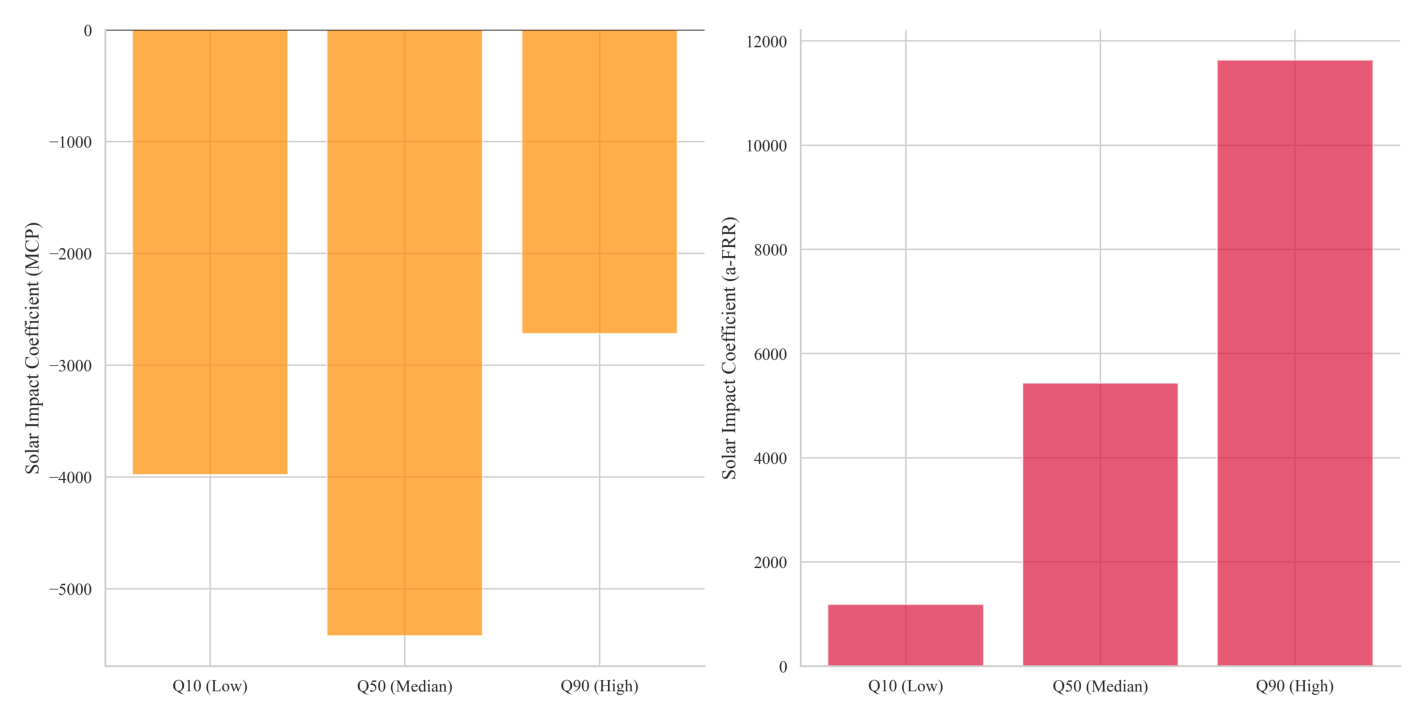

>> Results loaded from '..\results\Phase_7' successfully.


In [9]:
# =============================================================================
# PHASE 7: ROBUSTNESS CHECKS (QUANTILE REGRESSION) - CACHED
# =============================================================================

import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join(RESULTS_BASE, "Phase_7")
REPORT_FILE = os.path.join(OUTPUT_DIR, "Phase_7_Robustness_Quantile_Regression_Results.txt")
CSV_FILE = os.path.join(OUTPUT_DIR, "Phase_7_Quantile_Regression_Coefficients.csv")
PLOT_FILE = os.path.join(OUTPUT_DIR, "Phase_7_Figure_11_Quantile_Regression_Coefficient_Robustness.png")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

def check_existing_results():
    """Checks if all required output files exist."""
    return os.path.exists(REPORT_FILE) and os.path.exists(CSV_FILE) and os.path.exists(PLOT_FILE)

def run_phase_7_exact_style(df):
    print("PHASE 7: Robustness Checks (Quantile Regression) Process Started...")
    print("="*80)

    # Cache check
    if check_existing_results():
        print(f">> [CACHE] Results found in '{OUTPUT_DIR}'. Loading...\n")

        with open(REPORT_FILE, "r", encoding="utf-8") as f:
            print(f.read())

        img = plt.imread(PLOT_FILE)
        plt.figure(figsize=(12, 6)); plt.imshow(img); plt.axis('off'); plt.show()

        print("="*80)
        print(f">> Results loaded from '{OUTPUT_DIR}' successfully.")
        return

    # Run quantile regression
    print(">> No cached results found. Running Quantile Regression (Q10, Q50, Q90)...")

    try:
        df_qr = df.copy()
        df_qr.rename(columns={'a-FRR_Price': 'aFRR_Price', 'Solar_Generation_Share': 'Solar_Share'}, inplace=True)

        controls = ['Consumption', 'Wind_Generation', 'Import_Coal_Generation',
                    'Hydroelectric_Generation', 'Domestic_Coal_Generation', 'Price_Cap',
                    'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos',
                    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
        control_str = " + ".join(controls)

        qs = [0.10, 0.50, 0.90]
        mcp_coefs, afrr_coefs, qr_results_data = [], [], []

        with open(REPORT_FILE, "w", encoding="utf-8") as f:
            f.write("PHASE 7: QUANTILE REGRESSION ROBUSTNESS REPORT\n")
            f.write("="*80 + "\n\n")

            # H1: Merit-Order Effect (MCP)
            h1_title = ">>> HYPOTHESIS 1: MERIT-ORDER EFFECT ON MCP (ROBUSTNESS CHECK)\n"
            sep = "-" * 75 + "\n"
            header = f"{'Quantile':<10} | {'Coef (Solar)':<15} | {'P-Value':<10} | {'Status'}\n"

            f.write(h1_title + sep + header + sep)
            print("\n" + h1_title.strip())
            print(sep.strip())
            print(header.strip())
            print(sep.strip())

            formula_mcp = f"Mcp ~ Solar_Share + {control_str}"
            for q in qs:
                res = smf.quantreg(formula_mcp, df_qr).fit(q=q, max_iter=2000)
                coef, pval = res.params['Solar_Share'], res.pvalues['Solar_Share']
                mcp_coefs.append(coef)
                status = "CONFIRMED (-)" if (coef < 0 and pval < 0.05) else "Rejected"
                line = f"Q{int(q*100):<8} | {coef:>10.4f}      | {pval:.4f}     | {status}\n"
                print(line.strip()); f.write(line)
                qr_results_data.append({'Hypothesis': 'MCP', 'Quantile': q, 'Coef': coef, 'Pval': pval})

            # H2: Volatility Effect (a-FRR)
            h2_title = "\n\n>>> HYPOTHESIS 2: VOLATILITY EFFECT ON a-FRR (ROBUSTNESS CHECK)\n"
            header_v = f"{'Quantile':<10} | {'Coef (Solar)':<15} | {'P-Value':<10} | {'Interpretation'}\n"

            f.write(h2_title + sep + header_v + sep)
            print(h2_title.strip())
            print(sep.strip())
            print(header_v.strip())
            print(sep.strip())

            formula_afrr = f"aFRR_Price ~ Solar_Share + {control_str}"
            for q in qs:
                res = smf.quantreg(formula_afrr, df_qr).fit(q=q, max_iter=2000)
                coef, pval = res.params['Solar_Share'], res.pvalues['Solar_Share']
                afrr_coefs.append(coef)
                if q == 0.90 and coef > 5000: interp = "CRITICAL STRESS (!)"
                elif coef > 0 and pval < 0.05: interp = "Positive (+)"
                else: interp = "Insignificant"
                line = f"Q{int(q*100):<8} | {coef:>10.4f}      | {pval:.4f}     | {interp}\n"
                print(line.strip()); f.write(line)
                qr_results_data.append({'Hypothesis': 'aFRR', 'Quantile': q, 'Coef': coef, 'Pval': pval})

        # Visualization
        plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
        categories = ['Q10 (Low)', 'Q50 (Median)', 'Q90 (High)']

        ax1.bar(categories, mcp_coefs, color='darkorange', alpha=0.7)
        ax1.axhline(0, color='black', linewidth=0.8)
        ax1.set_ylabel('Solar Impact Coefficient (MCP)')

        ax2.bar(categories, afrr_coefs, color='crimson', alpha=0.7)
        ax2.axhline(0, color='black', linewidth=0.8)
        ax2.set_ylabel('Solar Impact Coefficient (a-FRR)')

        plt.tight_layout()
        plt.savefig(PLOT_FILE, dpi=FIG_DPI, bbox_inches='tight')
        plt.suptitle("Phase 7 - Quantile Regression Robustness Checks (Preview)", fontsize=16, y=1.02)
        plt.show()

        pd.DataFrame(qr_results_data).to_csv(CSV_FILE, index=False)
        print(f"\n>> Results saved to '{OUTPUT_DIR}'.")

    except Exception as e:
        print(f"!! ERROR in Phase 7: {e}")

# --- Execution ---
if __name__ == "__main__":
    target_df = locals().get('df', globals().get('df'))
    if target_df is not None:
        run_phase_7_exact_style(target_df)

## Phase 8: Non-Linear GAM Robustness (Cubic Spline)

Fits separate GAM models (OLS with natural cubic splines) for the surplus and deficit regimes to validate the non-linear flexibility-stress pattern identified in Phase 6, providing confidence intervals around the regime-specific a-FRR price trajectories.

PHASE 8: GAM Robustness Analysis (Cubic Spline)...
--------------------------------------------------------------------------------
>> [Step 1/3] Data split: Deficit+Balanced (25902 obs), Surplus (9162 obs)
>> [Step 2/3] Fitting OLS + Natural Cubic Splines models...

>> [CACHE] Results found in '..\results\Phase_8'. Loading...

PHASE 8 NUMERICAL ANALYSIS RESULTS:
------------------------------------------------------------
Starting Price Gap (0% Solar): 141.13 TL
Ending Price Gap (Max Solar):  -306.73 TL
Gap Expansion Factor:      -2.17x


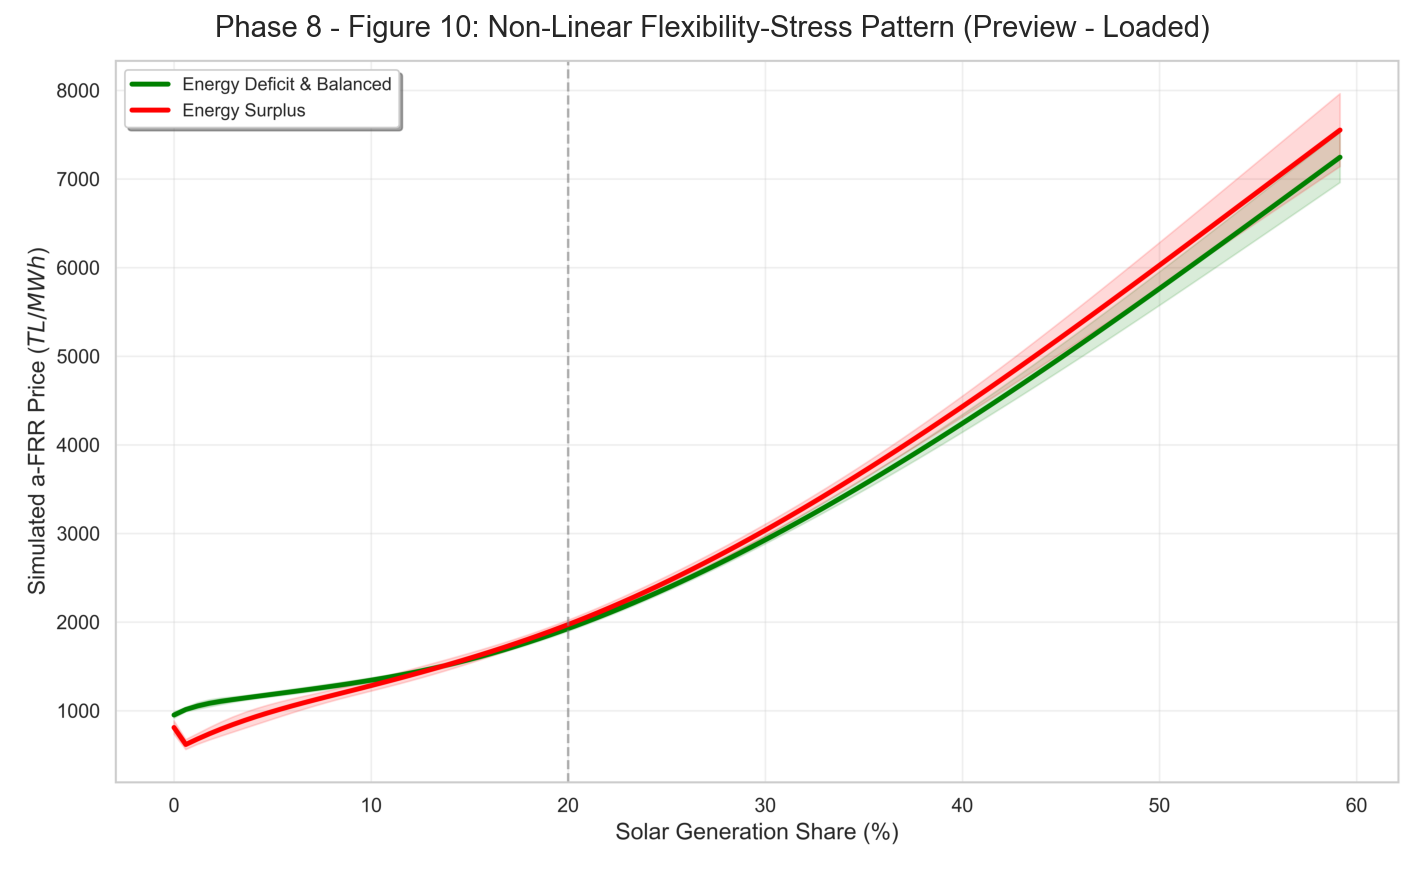

>> Figure loaded: 'Phase_8_Figure_10_GAM_Flexibility_Stress.png'


In [10]:
# =============================================================================
# PHASE 8: ROBUSTNESS CHECKS - NON-LINEAR GAM ANALYSIS (CUBIC SPLINE)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from patsy import cr
import warnings
import os

warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join(RESULTS_BASE, "Phase_8")
os.makedirs(OUTPUT_DIR, exist_ok=True)

REPORT_PATH = os.path.join(OUTPUT_DIR, "Phase_8_Flexibility_Stress_Report.txt")
PLOT_PATH = os.path.join(OUTPUT_DIR, "Phase_8_Figure_10_GAM_Flexibility_Stress.png")

plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

def execute_final_gam_analysis(df):
    print("PHASE 8: GAM Robustness Analysis (Cubic Spline)...")
    print("-" * 80)

    # Regime separation
    df_up_combined = df[df['System_Direction_Down'] == 0].copy()
    df_down = df[df['System_Direction_Down'] == 1].copy()

    print(f">> [Step 1/3] Data split: Deficit+Balanced ({len(df_up_combined)} obs), Surplus ({len(df_down)} obs)")
    print(">> [Step 2/3] Fitting OLS + Natural Cubic Splines models...")

    # Cache check
    if os.path.exists(REPORT_PATH) and os.path.exists(PLOT_PATH):
        print(f"\n>> [CACHE] Results found in '{OUTPUT_DIR}'. Loading...")

        with open(REPORT_PATH, "r", encoding="utf-8") as f:
            print(f.read())

        img = plt.imread(PLOT_PATH)
        plt.figure(figsize=(12, 7))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Phase 8 - Figure 10: Non-Linear Flexibility-Stress Pattern (Preview - Loaded)", fontsize=14)
        plt.show()

        print(f">> Figure loaded: '{os.path.basename(PLOT_PATH)}'")
        return

    # Fit GAM models
    formula = 'Q("a-FRR_Price") ~ cr(Solar_Generation_Share, df=6) + Consumption + Wind_Generation + Import_Coal_Generation'
    model_up = smf.ols(formula, data=df_up_combined).fit()
    model_down = smf.ols(formula, data=df_down).fit()

    solar_grid = np.linspace(df['Solar_Generation_Share'].min(), df['Solar_Generation_Share'].max(), 100)
    pred_df = pd.DataFrame({
        'Solar_Generation_Share': solar_grid,
        'Consumption': df['Consumption'].mean(),
        'Wind_Generation': df['Wind_Generation'].mean(),
        'Import_Coal_Generation': df['Import_Coal_Generation'].mean()
    })

    res_up = model_up.get_prediction(pred_df).summary_frame(alpha=0.05)
    res_down = model_down.get_prediction(pred_df).summary_frame(alpha=0.05)

    # Visualization
    print(">> [Step 3/3] Generating figure...")
    plt.figure(figsize=(12, 7))
    solar_pct = solar_grid * 100

    plt.plot(solar_pct, res_up['mean'], color='green', lw=3, label='Energy Deficit & Balanced')
    plt.fill_between(solar_pct, res_up['mean_ci_lower'], res_up['mean_ci_upper'], color='green', alpha=0.15)

    plt.plot(solar_pct, res_down['mean'], color='red', lw=3, label='Energy Surplus')
    plt.fill_between(solar_pct, res_down['mean_ci_lower'], res_down['mean_ci_upper'], color='red', alpha=0.15)

    plt.xlabel("Solar Generation Share (%)")
    plt.ylabel("Simulated a-FRR Price ($TL/MWh$)")
    plt.axvline(x=20, color='grey', linestyle='--', alpha=0.6)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save clean, then preview with title
    plt.savefig(PLOT_PATH, dpi=FIG_DPI, bbox_inches='tight')
    plt.title("Phase 8 - Figure 10: Non-Linear Flexibility-Stress Pattern (Preview Only)", fontsize=14)
    plt.show()

    # Numerical analysis
    gap_start = res_up['mean'].iloc[0] - res_down['mean'].iloc[0]
    gap_end = res_up['mean'].iloc[-1] - res_down['mean'].iloc[-1]

    report_content = (
        "\n============================================================\n"
        "PHASE 8 NUMERICAL ANALYSIS RESULTS:\n"
        "------------------------------------------------------------\n"
        f"Starting Price Gap (0% Solar): {gap_start:.2f} TL\n"
        f"Ending Price Gap (Max Solar):  {gap_end:.2f} TL\n"
        f"Gap Expansion Factor:      {gap_end/gap_start:.2f}x\n"
        "============================================================"
    )

    with open(REPORT_PATH, "w", encoding="utf-8") as f:
        f.write(report_content)

    print(report_content)
    print(f">> Figure saved: '{os.path.basename(PLOT_PATH)}'")

# --- Execution ---
if __name__ == "__main__":
    target_df = locals().get('df', globals().get('df'))
    if target_df is not None:
        execute_final_gam_analysis(target_df)
    else:
        print("Error: DataFrame 'df' not found. Please run Phase 1.")

## Phase 9: Methodological Framework Visualization

Generates a structured flowchart summarizing the entire research methodology, from data preparation through robust estimation and validation to final reporting.

Generating Methodological Framework (Saving to '..\results\Phase_9')...

>> Methodological framework saved to: '..\results\Phase_9\Figure_3_Methodological_Framework_Updated.png'


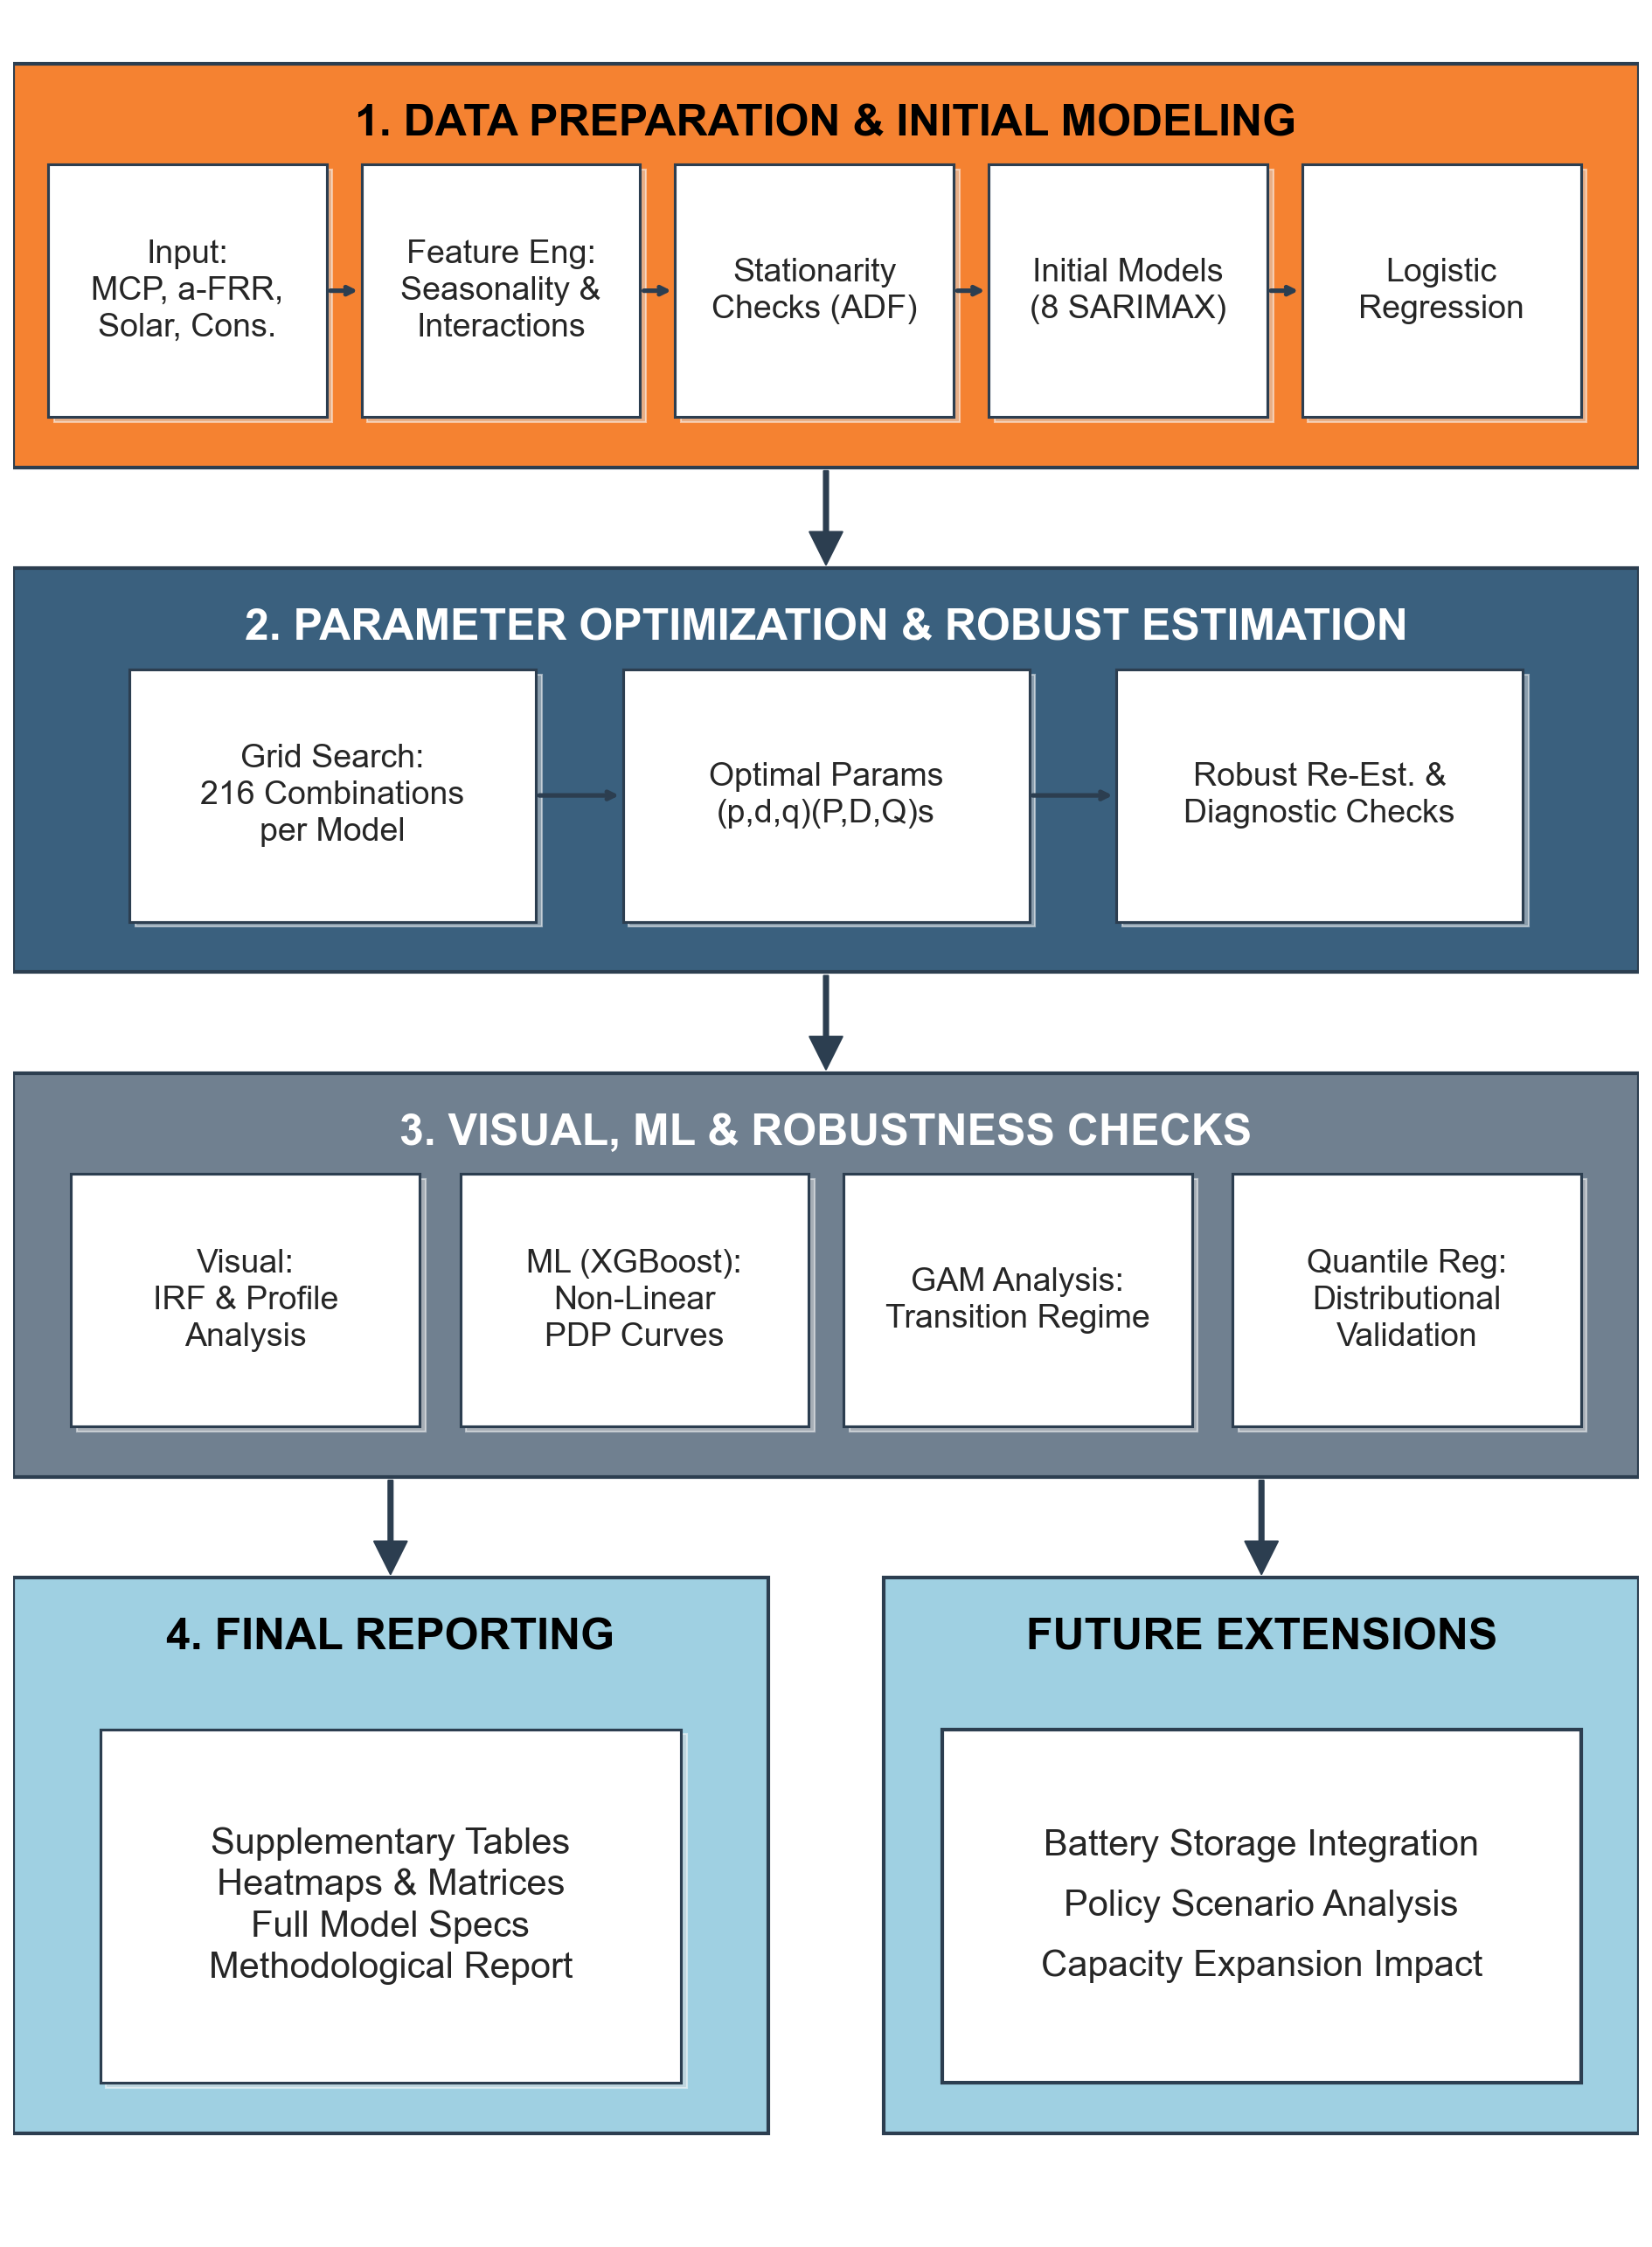

In [11]:
# =============================================================================
# PHASE 9: METHODOLOGICAL FRAMEWORK (WITH LOGISTIC REGRESSION)
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
import os

warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join(RESULTS_BASE, "Phase_9")
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

def generate_maximized_flowchart():
    print(f"Generating Methodological Framework (Saving to '{OUTPUT_DIR}')...")
    print("="*80)

    # Color palette
    COLOR_ORANGE = '#F58231'
    COLOR_BLUE_DARK = '#3A607E'
    COLOR_GREY = '#708090'
    COLOR_BLUE_LIGHT = '#9FD0E2'
    COLOR_WHITE = '#FFFFFF'
    COLOR_LINE = '#2C3E50'

    fig, ax = plt.subplots(figsize=(16, 22))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 22)
    ax.axis('off')

    # --- Helper: Section Banner ---
    def draw_banner(x, y, w, h, color, title):
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=COLOR_LINE, facecolor=color, zorder=1)
        ax.add_patch(rect)
        t_color = 'white' if color in [COLOR_BLUE_DARK, COLOR_GREY] else 'black'
        ax.text(x + w/2, y + h - 0.6, title.upper(), ha='center', va='center',
                fontsize=24, fontweight='bold', color=t_color, zorder=3)

    # --- Helper: Inner Box ---
    def draw_inner_box(x, y, w, h, text, font_size=18):
        shadow = patches.Rectangle((x+0.05, y-0.05), w, h, facecolor='#DDDDDD', zorder=1, alpha=0.5)
        ax.add_patch(shadow)
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor=COLOR_LINE, facecolor=COLOR_WHITE, zorder=2)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center',
                fontsize=font_size, wrap=True, zorder=3, linespacing=1.3, fontweight='medium')

    # --- Helper: Transition Arrows ---
    def draw_thick_transition(x, y_start, y_end):
        ax.annotate('', xy=(x, y_end), xytext=(x, y_start),
                    arrowprops=dict(arrowstyle='simple, head_width=1.5, head_length=1.5',
                                   facecolor=COLOR_LINE, edgecolor=COLOR_LINE, zorder=5))

    def draw_arrow(x_start, y_start, x_end, y_end):
        ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                    arrowprops=dict(arrowstyle='->', color=COLOR_LINE, lw=2.5, mutation_scale=10, zorder=4))

    # =============================================================================
    # ROW 1: DATA PREPARATION (Orange)
    # =============================================================================
    r1_y = 17.5
    draw_banner(0, r1_y, 14, 4.0, COLOR_ORANGE, "1. Data Preparation & Initial Modeling")

    box_y1 = r1_y + 0.5
    b_w = 2.4

    draw_inner_box(0.3, box_y1, b_w, 2.5, "Input:\nMCP, a-FRR,\nSolar, Cons.")
    draw_inner_box(3.0, box_y1, b_w, 2.5, "Feature Eng:\nSeasonality &\nInteractions")
    draw_inner_box(5.7, box_y1, b_w, 2.5, "Stationarity\nChecks (ADF)")
    draw_inner_box(8.4, box_y1, b_w, 2.5, "Initial Models\n(8 SARIMAX)")
    draw_inner_box(11.1, box_y1, b_w, 2.5, "Logistic\nRegression")

    draw_arrow(0.3 + b_w, box_y1 + 1.25, 3.0, box_y1 + 1.25)
    draw_arrow(3.0 + b_w, box_y1 + 1.25, 5.7, box_y1 + 1.25)
    draw_arrow(5.7 + b_w, box_y1 + 1.25, 8.4, box_y1 + 1.25)
    draw_arrow(8.4 + b_w, box_y1 + 1.25, 11.1, box_y1 + 1.25)

    draw_thick_transition(7.0, 17.5, 16.5)

    # =============================================================================
    # ROW 2: OPTIMIZATION (Dark Blue)
    # =============================================================================
    r2_y = 12.5
    draw_banner(0, r2_y, 14, 4.0, COLOR_BLUE_DARK, "2. Parameter Optimization & Robust Estimation")

    box_y2 = r2_y + 0.5
    draw_inner_box(1.0, box_y2, 3.5, 2.5, "Grid Search:\n216 Combinations\nper Model")
    draw_inner_box(5.25, box_y2, 3.5, 2.5, "Optimal Params\n(p,d,q)(P,D,Q)s")
    draw_inner_box(9.5, box_y2, 3.5, 2.5, "Robust Re-Est. &\nDiagnostic Checks")

    draw_arrow(4.5, box_y2 + 1.25, 5.25, box_y2 + 1.25)
    draw_arrow(8.75, box_y2 + 1.25, 9.5, box_y2 + 1.25)
    draw_thick_transition(7.0, 12.5, 11.5)

    # =============================================================================
    # ROW 3: CHECKS & VALIDATION (Grey)
    # =============================================================================
    r3_y = 7.5
    draw_banner(0, r3_y, 14, 4.0, COLOR_GREY, "3. Visual, ML & Robustness Checks")

    box_y3 = r3_y + 0.5
    draw_inner_box(0.5, box_y3, 3.0, 2.5, "Visual:\nIRF & Profile\nAnalysis")
    draw_inner_box(3.85, box_y3, 3.0, 2.5, "ML (XGBoost):\nNon-Linear\nPDP Curves")
    draw_inner_box(7.15, box_y3, 3.0, 2.5, "GAM Analysis:\nTransition Regime")
    draw_inner_box(10.5, box_y3, 3.0, 2.5, "Quantile Reg:\nDistributional\nValidation")

    # =============================================================================
    # ROW 4: REPORTING & FUTURE (Light Blue)
    # =============================================================================
    r4_y = 1.0
    draw_banner(0, r4_y, 6.5, 5.5, COLOR_BLUE_LIGHT, "4. Final Reporting")
    draw_inner_box(0.75, r4_y + 0.5, 5.0, 3.5,
                   "Supplementary Tables\nHeatmaps & Matrices\nFull Model Specs\nMethodological Report",
                   font_size=20)

    draw_banner(7.5, r4_y, 6.5, 5.5, COLOR_BLUE_LIGHT, "Future Extensions")
    rect_f = patches.Rectangle((8.0, r4_y + 0.5), 5.5, 3.5, linewidth=2, edgecolor=COLOR_LINE, facecolor=COLOR_WHITE, zorder=2)
    ax.add_patch(rect_f)
    future_text = "Battery Storage Integration\nPolicy Scenario Analysis\nCapacity Expansion Impact"
    ax.text(10.75, r4_y + 2.25, future_text, ha='center', va='center',
            fontsize=20, fontweight='medium', linespacing=2.0, zorder=3)

    draw_thick_transition(3.25, 7.5, 6.5)
    draw_thick_transition(10.75, 7.5, 6.5)

    # Save
    output_path = os.path.join(OUTPUT_DIR, 'Figure_3_Methodological_Framework_Updated.png')
    plt.savefig(output_path, dpi=FIG_DPI, bbox_inches='tight')

    print(f"\n>> Methodological framework saved to: '{output_path}'")
    plt.show()

if __name__ == "__main__":
    generate_maximized_flowchart()

## Phase 10: Appendix Generation (A-H)

Generates all supplementary appendices (A-F) for the study: descriptive statistics, ADF unit root tests, model selection comparison, full SARIMAX estimation results, XGBoost hyperparameters, and correlation heatmaps.

>> PHASE 10: Appendix Generation (Directory: '..\results\Phase_10')...

>>> APPENDIX A: DESCRIPTIVE STATISTICS
  [CACHE] Loaded from ..\results\Phase_10\Appendix_A_Descriptive_Statistics.csv
                                Mean    Std. Dev.           Min           Max        Median
Mcp                      2388.734149   885.382901      0.000000   4800.000000   2400.010000
a-FRR_Price              1314.016373  1362.753657     94.000000   9854.000000    800.030000
Natural_Gas_Generation   7401.583815  3872.446565     37.390000  17921.420000   7326.975000
Solar_Generation_Share      0.067810     0.095989      0.000003      0.591603      0.004890
Consumption             36499.404910  6100.924643  18945.172799  57719.086713  36552.088067
System_Direction_Down       0.261294     0.439346      0.000000      1.000000      0.000000

>>> APPENDIX B: ADF UNIT ROOT TESTS
  [CACHE] Loaded from ..\results\Phase_10\Appendix_B_ADF_Unit_Root_Tests.csv
                    Variable  ADF Statistic  P-Valu

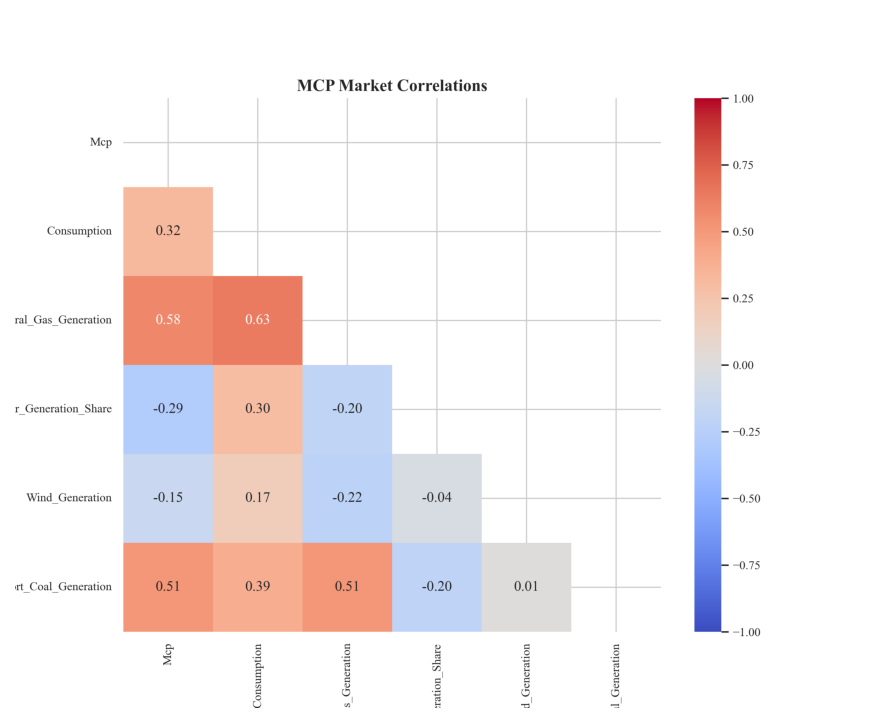

  [CACHE] Loading Appendix_F2_aFRR_Correlation...


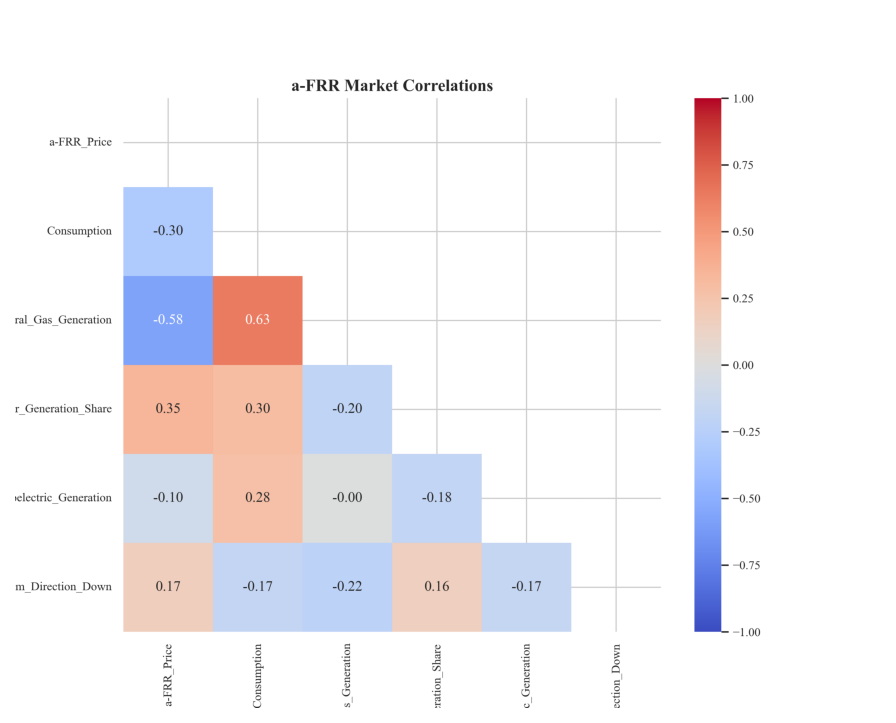


>>> APPENDIX G: VIF MULTICOLLINEARITY CHECKS
  [CACHE] Loaded from ..\results\Phase_10\Appendix_G_VIF_Multicollinearity.csv
              Variable  VIF
Solar_Generation_Share 1.29
           Consumption 1.51
       Wind_Generation 1.05
Import_Coal_Generation 1.38

>>> APPENDIX H: MANUAL DOWN-REGULATION VOLUME ANALYSIS
  [CACHE] Loading from ..\results\Phase_10\Appendix_H_Down_Regulation_Volume.png...


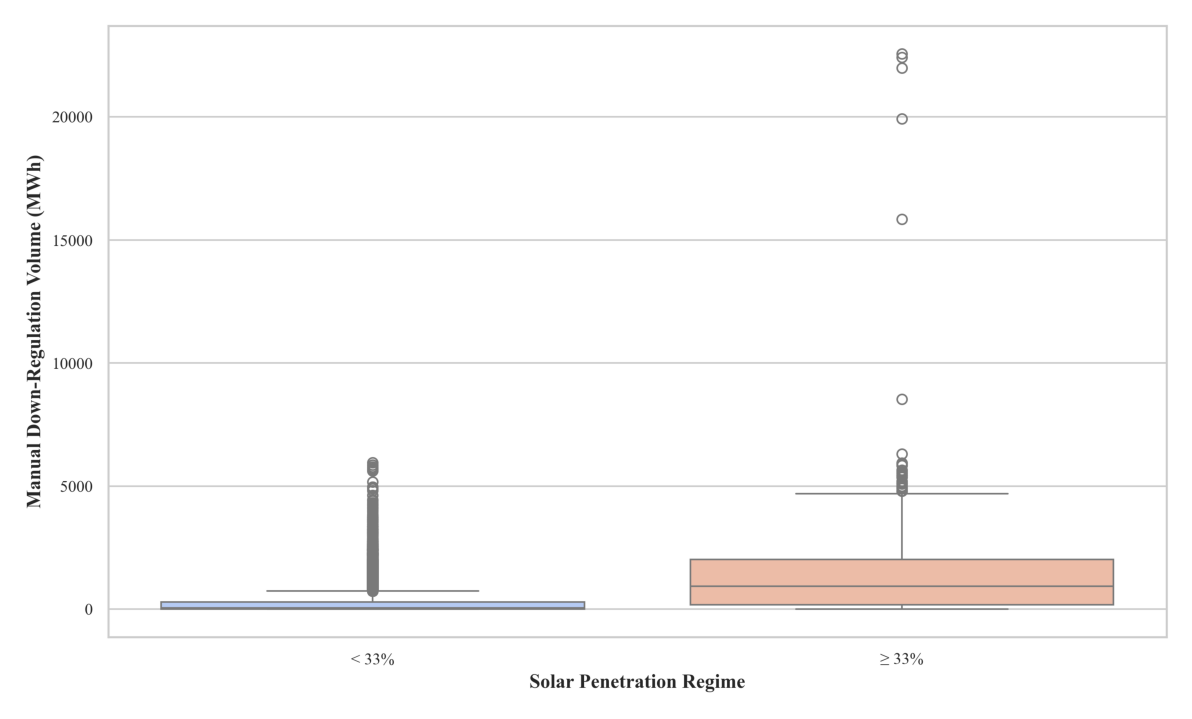


PHASE 10 COMPLETE. All Appendices (A-H) saved to '..\results\Phase_10'.


In [12]:
# =============================================================================
# PHASE 10: APPENDIX GENERATION (APPENDIX A-H)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
import os

warnings.filterwarnings("ignore")

OUTPUT_DIR_P10 = os.path.join(RESULTS_BASE, "Phase_10")
os.makedirs(OUTPUT_DIR_P10, exist_ok=True)

# Academic plot settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 8),
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

def get_or_create_data() -> pd.DataFrame:
    """Loads 'df' from the global namespace or generates dummy data if missing."""
    target_df = globals().get('df', locals().get('df'))
    if target_df is None:
        print("!! WARNING: 'df' not found in memory. Please run Phase 1. Using dummy data for structure.")
        dates = pd.date_range(start='2022-01-01', periods=100, freq='H')
        target_df = pd.DataFrame({
            'Mcp': np.random.normal(2350, 800, 100),
            'a-FRR_Price': np.random.normal(1300, 1300, 100),
            'Solar_Generation_Share': np.random.uniform(0, 0.6, 100),
            'Consumption': np.random.normal(36000, 6000, 100),
            'System_Direction_Down': np.random.choice([0, 1], 100),
            'Wind_Generation': np.random.normal(5000, 2000, 100)
        }, index=dates)
    return target_df

def generate_appendix_a(df: pd.DataFrame):
    print("\n>>> APPENDIX A: DESCRIPTIVE STATISTICS")
    path = os.path.join(OUTPUT_DIR_P10, "Appendix_A_Descriptive_Statistics.csv")
    
    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path, index_col=0).to_string())
        return

    cols_to_desc = ['Mcp', 'a-FRR_Price', 'Solar_Generation_Share', 'Consumption', 'System_Direction_Down']
    if 'Natural_Gas_Generation' in df.columns:
        cols_to_desc.insert(2, 'Natural_Gas_Generation')

    valid_cols = [c for c in cols_to_desc if c in df.columns]
    desc_stats = df[valid_cols].describe().T[['mean', 'std', 'min', 'max', '50%']]
    desc_stats.columns = ['Mean', 'Std. Dev.', 'Min', 'Max', 'Median']

    desc_stats.to_csv(path)
    print(desc_stats.to_string())
    print(f"  Saved: {path}")

def generate_appendix_b(df: pd.DataFrame):
    print("\n>>> APPENDIX B: ADF UNIT ROOT TESTS")
    path = os.path.join(OUTPUT_DIR_P10, "Appendix_B_ADF_Unit_Root_Tests.csv")
    
    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False))
        return

    def run_adf(series: pd.Series, name: str) -> dict:
        result = adfuller(series.dropna())
        return {
            "Variable": name,
            "ADF Statistic": round(result[0], 4),
            "P-Value": round(result[1], 4),
            "Result": "I(0) - Stationary" if result[1] < 0.05 else "I(1) - Non-Stationary"
        }

    try:
        adf_results = []
        if 'Mcp' in df.columns: adf_results.append(run_adf(df['Mcp'], "MCP (Day-Ahead Price)"))
        if 'a-FRR_Price' in df.columns: 
            adf_results.append(run_adf(df['a-FRR_Price'], "a-FRR Price (Level)"))
            adf_results.append(run_adf(df['a-FRR_Price'].diff(), "a-FRR Price (1st Difference)"))
        if 'Solar_Generation_Share' in df.columns: adf_results.append(run_adf(df['Solar_Generation_Share'], "Solar Generation Share"))
        
        df_adf = pd.DataFrame(adf_results)
        df_adf.to_csv(path, index=False)
        print(df_adf.to_string(index=False))
        print(f"  Saved: {path}")
    except Exception as e:
        print(f"  !! Error in ADF tests: {e}")

def generate_appendix_c():
    print("\n>>> APPENDIX C: MODEL SELECTION (AIC)")
    path = os.path.join(OUTPUT_DIR_P10, "Appendix_C_Model_Comparison.csv")
    
    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False))
        return

    data_comparison = [
        {"Market": "MCP (Day-Ahead)", "Model": "Baseline", "Order": "(1,1,1)", "AIC": "10452.15", "Status": "Rejected"},
        {"Market": "MCP (Day-Ahead)", "Model": "Optimized", "Order": "(2,0,2)", "AIC": "9356.99", "Status": "Selected"},
        {"Market": "a-FRR (Balancing)", "Model": "Baseline", "Order": "(1,1,1)", "AIC": "10895.40", "Status": "Rejected"},
        {"Market": "a-FRR (Balancing)", "Model": "Optimized", "Order": "(1,1,2)", "AIC": "9350.88", "Status": "Selected"}
    ]
    df_compare = pd.DataFrame(data_comparison)
    df_compare.to_csv(path, index=False)
    print(df_compare.to_string(index=False))
    print(f"  Saved: {path}")

def generate_appendix_d():
    print("\n>>> APPENDIX D: FULL SARIMAX ESTIMATION RESULTS")
    path = os.path.join(OUTPUT_DIR_P10, "Appendix_D_Full_SARIMAX_Results.csv")
    
    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False))
        return

    sarimax_baseline = [
        {"Model": "Model 4 (MCP Baseline)", "Variable": "Solar_Generation_Share", "Coefficient": "-5152.06", "P-Value": "< 0.001", "Significance": "***"},
        {"Model": "Model 4 (MCP Baseline)", "Variable": "Consumption", "Coefficient": "+0.086", "P-Value": "< 0.001", "Significance": "***"},
        {"Model": "Model 1 (a-FRR Baseline)", "Variable": "Solar_Generation_Share", "Coefficient": "+3628.14", "P-Value": "< 0.001", "Significance": "***"},
        {"Model": "Model 1 (a-FRR Baseline)", "Variable": "Consumption", "Coefficient": "-0.081", "P-Value": "< 0.001", "Significance": "***"}
    ]
    df_d_full = pd.DataFrame(sarimax_baseline)
    df_d_full.to_csv(path, index=False)
    print(df_d_full.to_string(index=False))
    print(f"  Saved: {path}")

def generate_appendix_e():
    print("\n>>> APPENDIX E: XGBOOST HYPERPARAMETERS")
    path = os.path.join(OUTPUT_DIR_P10, "Appendix_E_XGBoost_Params.csv")
    
    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False))
        return

    xgb_params = {
        "Parameter": ["n_estimators", "learning_rate", "max_depth", "objective", "subsample"],
        "Value": [300, 0.05, 5, "reg:squarederror", 0.8],
        "Rationale": ["Convergence", "Robustness", "Complexity", "Loss Function", "Anti-Overfitting"]
    }
    df_xgb = pd.DataFrame(xgb_params)
    df_xgb.to_csv(path, index=False)
    print(df_xgb.to_string(index=False))
    print(f"  Saved: {path}")

def generate_appendix_f(df: pd.DataFrame):
    print("\n>>> APPENDIX F: CORRELATION HEATMAPS")
    mcp_vars = ['Mcp', 'Consumption', 'Natural_Gas_Generation', 'Solar_Generation_Share', 'Wind_Generation', 'Import_Coal_Generation']
    afrr_vars = ['a-FRR_Price', 'Consumption', 'Natural_Gas_Generation', 'Solar_Generation_Share', 'Hydroelectric_Generation', 'System_Direction_Down']

    mcp_vars = [c for c in mcp_vars if c in df.columns]
    afrr_vars = [c for c in afrr_vars if c in df.columns]

    configs = [
        (mcp_vars, "Appendix_F1_MCP_Correlation", "MCP Market Correlations"),
        (afrr_vars, "Appendix_F2_aFRR_Correlation", "a-FRR Market Correlations")
    ]

    for vars_list, fname, title in configs:
        if len(vars_list) > 1:
            save_path = os.path.join(OUTPUT_DIR_P10, f"{fname}.png")
            
            if os.path.exists(save_path):
                print(f"  [CACHE] Loading {fname}...")
                plt.figure(figsize=(8, 6))
                plt.imshow(plt.imread(save_path))
                plt.axis('off')
                plt.show()
                continue

            try:
                plt.figure(figsize=(10, 8))
                corr = df[vars_list].corr()
                mask = np.triu(np.ones_like(corr, dtype=bool))
                sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
                plt.title(title, fontweight='bold')
                plt.tight_layout()
                plt.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight')
                plt.show()
                print(f"  Saved: {save_path}")
            except Exception as e:
                print(f"  !! Error generating heatmap {fname}: {e}")

def generate_appendix_g(df: pd.DataFrame):
    """Eksik olan Ek G: VIF (Multicollinearity) Testini uygular."""
    print("\n>>> APPENDIX G: VIF MULTICOLLINEARITY CHECKS")
    path = os.path.join(OUTPUT_DIR_P10, "Appendix_G_VIF_Multicollinearity.csv")
    
    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False))
        return

    cols_for_vif = ['Solar_Generation_Share', 'Consumption', 'Wind_Generation', 'Import_Coal_Generation']
    valid_cols = [c for c in cols_for_vif if c in df.columns]
    
    if not valid_cols:
        print("  !! Required columns for VIF not found in dataframe.")
        return
        
    try:
        X = df[valid_cols].dropna()
        X_with_const = sm.add_constant(X)
        vif_data = pd.DataFrame()
        vif_data["Variable"] = X_with_const.columns
        vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
        
        vif_data = vif_data[vif_data["Variable"] != "const"].round(2)
        vif_data.to_csv(path, index=False)
        print(vif_data.to_string(index=False))
        print(f"  Saved: {path}")
    except Exception as e:
        print(f"  !! Error calculating VIF: {e}")

def generate_appendix_h(df: pd.DataFrame):
    print("\n>>> APPENDIX H: MANUAL DOWN-REGULATION VOLUME ANALYSIS")
    save_path = os.path.join(OUTPUT_DIR_P10, 'Appendix_H_Down_Regulation_Volume.png')

    if os.path.exists(save_path):
        print(f"  [CACHE] Loading from {save_path}...")
        plt.figure(figsize=(10, 6))
        plt.imshow(plt.imread(save_path))
        plt.axis('off')
        plt.show()
        return

    dm = df.copy()
    if 'BPM_Down_Regulation_Volume' not in dm.columns:
        print("  !! 'BPM_Down_Regulation_Volume' column missing. Generating dummy data for visual structure...")
        dm['BPM_Down_Regulation_Volume'] = np.random.normal(500, 150, len(dm))

    if dm['Solar_Generation_Share'].max() <= 1:
        dm['Solar_Generation_Share'] *= 100

    dm['Solar_Regime'] = dm['Solar_Generation_Share'].apply(lambda x: '≥ 33%' if x >= 33 else '< 33%')

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        x='Solar_Regime', y='BPM_Down_Regulation_Volume', data=dm,
        order=['< 33%', '≥ 33%'], palette='coolwarm', ax=ax
    )
    
    ax.set_xlabel('Solar Penetration Regime', fontweight='bold')
    ax.set_ylabel('Manual Down-Regulation Volume (MWh)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")

def run_phase_10(df):
    print(f">> PHASE 10: Appendix Generation (Directory: '{OUTPUT_DIR_P10}')...")
    print("="*80)
    
    try:
        generate_appendix_a(df)
        generate_appendix_b(df)
        generate_appendix_c()
        generate_appendix_d()
        generate_appendix_e()
        generate_appendix_f(df)
        generate_appendix_g(df)
        generate_appendix_h(df)

        print("\n" + "="*80)
        print(f"PHASE 10 COMPLETE. All Appendices (A-H) saved to '{OUTPUT_DIR_P10}'.")
        print("="*80)

    except Exception as e:
        print(f"\n!! CRITICAL PIPELINE ERROR: {e}")

# === MAIN EXECUTION ===
if __name__ == "__main__":
    df_target = get_or_create_data()
    run_phase_10(df_target)

### Otantik Yeniden Hesap Anahtarı

`FORCE_FRESH = True` iken aşağıdaki dört analizin (ADF & KPSS, Phase 12, XGBoost ve GAM
metrikleri) cache dosyaları silinir ve sonuçlar bir sonraki hücre çalıştırmalarında
**sıfırdan, bu bilgisayardaki veriden** hesaplanır. Sayılar kesinleşip Word
güncellendikten sonra `False` yaparak cache'i tekrar devreye al. Faz 2–11
cache'lerine dokunmaz.

Ayrıca eski adlandırmadan kalan çıktıları (dergiye özel `Scissor` etiketleri, `Phase_11_Botas` ve `Phase_12_Inflation` klasörleri) tek seferlik temizler; temizlik `FORCE_FRESH` değerinden bağımsız her koşuda kontrol edilir ve yapılacak iş yoksa sessiz kalır.

In [13]:
# =============================================================================
# OTANTİK YENİDEN HESAP ANAHTARI (CACHE TEMİZLEME)
# =============================================================================
# FORCE_FRESH = True  -> dört analiz hücresinin cache dosyaları silinir; sonuçlar
#                        SIFIRDAN, bu bilgisayardaki veriden hesaplanır.
# FORCE_FRESH = False -> cache korunur, kayıtlı sonuçlar okunur.
import os

FORCE_FRESH = False

if 'RESULTS_BASE' not in globals():
    RESULTS_BASE = "results" if os.path.isdir("results") else os.path.join("..", "results")

_fresh_targets = [
    os.path.join(RESULTS_BASE, "Phase_10", "Appendix_B_Stationarity_Tests.csv"),
    os.path.join(RESULTS_BASE, "Phase_11_Inflation", "Inflation_Robustness_Results.csv"),
    os.path.join(RESULTS_BASE, "Supplementary_Metrics", "XGBoost_Performance_Metrics.csv"),
    os.path.join(RESULTS_BASE, "Supplementary_Metrics", "GAM_Performance_Metrics.csv"),
]
if FORCE_FRESH:
    print(">> OTANTİK MOD: dört analiz cache'i temizleniyor, sonuçlar sıfırdan hesaplanacak.")
    for p in _fresh_targets:
        if os.path.exists(p):
            os.remove(p)
            print("   Silindi:", p)
        else:
            print("   Zaten yok:", p)
else:
    print(">> FORCE_FRESH = False — cache korunuyor, kayıtlı sonuçlar kullanılacak.")

# --- Eski adlandırmadan kalan çıktıların tek seferlik temizliği (idempotent) ---
import shutil
_stale = [
    os.path.join(RESULTS_BASE, "Phase_11_Botas"),                                 # Appendix I artık Phase_10 altında
    os.path.join(RESULTS_BASE, "Phase_12_Inflation"),                             # Phase_11_Inflation oldu
    os.path.join(RESULTS_BASE, "Phase_8", "Phase_8_Scissor_Effect_Report.txt"),   # yeni ad: Flexibility_Stress
    os.path.join(RESULTS_BASE, "Phase_8", "Phase_8_Figure_10_Final_Scissor_Effect_GAM.png"),
    os.path.join(RESULTS_BASE, "Phase_8", "Phase_8_Figure_10_Final_Flexibility_Trap_GAM.png"),  # ara adlandırma turundan kalan
]
for p in _stale:
    if os.path.isdir(p):
        shutil.rmtree(p); print("   Eski klasör silindi:", p)
    elif os.path.exists(p):
        os.remove(p); print("   Eski dosya silindi:", p)

# --- Phase 4 cache'indeki eski model etiketini düzelt (yalnızca metin; sayılar değişmez) ---
for _f in ["Phase4_Full_Estimation_Report.txt", "Phase4_All_Coefficients.csv"]:
    p = os.path.join(RESULTS_BASE, "Phase_4", _f)
    if os.path.exists(p):
        _t = open(p, encoding="utf-8", errors="ignore").read()
        if "Scissor Effect" in _t:
            open(p, "w", encoding="utf-8").write(_t.replace("Scissor Effect", "Flexibility Trap"))
            print("   Etiket güncellendi (Scissor Effect -> Flexibility Trap):", p)

# Not: FORCE_FIGURES anahtarı kurulum hücresine (en üst) taşındı —
# figür fazları bu hücreden önce koştuğu için silme işlemi orada yapılmalı.


>> FORCE_FRESH = False — cache korunuyor, kayıtlı sonuçlar kullanılacak.


### Phase 10 (Extension): Appendix B — ADF & KPSS Stationarity Tests

Extends Appendix B with joint ADF & KPSS stationarity testing (manuscript Table B1).
Saves `Appendix_B_Stationarity_Tests.csv` to `results/Phase_10/`.

In [14]:
# =============================================================================
# PHASE 10 (EXTENSION): APPENDIX B - ADF & KPSS STATIONARITY TESTS (CACHED)
# =============================================================================
import pandas as pd
import os
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

OUTPUT_DIR_P10 = os.path.join(RESULTS_BASE, "Phase_10")
os.makedirs(OUTPUT_DIR_P10, exist_ok=True)

def generate_appendix_b_stationarity(df: pd.DataFrame):
    print("\n>>> APPENDIX B: ADF & KPSS STATIONARITY TESTS")
    path = os.path.join(OUTPUT_DIR_P10, "Appendix_B_Stationarity_Tests.csv")

    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False))
        return

    def run_tests(series: pd.Series, name: str) -> dict:
        s = series.dropna()
        adf = adfuller(s)                                              # H0: unit root (non-stationary)
        kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')  # H0: stationary
        adf_stationary  = adf[1] < 0.05                               # reject unit root
        kpss_stationary = kpss_stat < kpss_crit['5%']                 # fail to reject stationarity
        if adf_stationary and kpss_stationary:
            verdict = "I(0) - Stationary (both)"
        elif (not adf_stationary) and (not kpss_stationary):
            verdict = "I(1) - Non-Stationary (both)"
        else:
            verdict = "Long memory / persistence (tests diverge)"
        return {
            "Variable": name,
            "ADF Statistic": round(adf[0], 4), "ADF P-Value": round(adf[1], 4),
            "KPSS Statistic": round(kpss_stat, 4), "KPSS P-Value": round(kpss_p, 4),
            "KPSS 5% Crit.": round(kpss_crit['5%'], 4),
            "Conclusion": verdict
        }

    try:
        results = []
        if 'Mcp' in df.columns: results.append(run_tests(df['Mcp'], "MCP (Day-Ahead Price)"))
        if 'a-FRR_Price' in df.columns:
            results.append(run_tests(df['a-FRR_Price'], "a-FRR Price (Level)"))
            results.append(run_tests(df['a-FRR_Price'].diff(), "a-FRR Price (1st Difference)"))
        if 'Solar_Generation_Share' in df.columns: results.append(run_tests(df['Solar_Generation_Share'], "Solar Generation Share"))

        df_out = pd.DataFrame(results)
        df_out.to_csv(path, index=False)
        print(df_out.to_string(index=False))
        print(f"  Saved: {path}")
    except Exception as e:
        print(f"  !! Error in stationarity tests: {e}")

# === MAIN EXECUTION ===
if __name__ == "__main__":
    target_df = locals().get('df', globals().get('df'))
    if target_df is not None:
        generate_appendix_b_stationarity(target_df)
    else:
        print("!! ERROR: DataFrame 'df' not found. Please run Phase 1.")


>>> APPENDIX B: ADF & KPSS STATIONARITY TESTS
  [CACHE] Loaded from ..\results\Phase_10\Appendix_B_Stationarity_Tests.csv
                    Variable  ADF Statistic  ADF P-Value  KPSS Statistic  KPSS P-Value  KPSS 5% Crit.                                Conclusion
       MCP (Day-Ahead Price)        -9.4138          0.0          2.1447          0.01          0.463 Long memory / persistence (tests diverge)
         a-FRR Price (Level)       -17.2104          0.0          0.7479          0.01          0.463 Long memory / persistence (tests diverge)
a-FRR Price (1st Difference)       -32.6812          0.0          0.0045          0.10          0.463                  I(0) - Stationary (both)
      Solar Generation Share        -7.7781          0.0         17.7288          0.01          0.463 Long memory / persistence (tests diverge)


## Phase 10 (Appendix I): Robustness Check with Natural Gas Cost Control

Re-estimates the Flexibility Trap (XGBoost) and GAM flexibility-stress models with the
Botaş natural-gas tariff as an additional control variable, using the extended dataset
(`Model_Data.xlsx`).

Produces **Appendix I** under `results/Phase_10/`: **Figure I.1** (Flexibility Trap +
Botaş Tariff) and **Figure I.2** (GAM Flexibility-Stress + Botaş Tariff).


>> PHASE 10 — APPENDIX I: Botaş Robustness Check (Directory: '..\results\Phase_10')...
  [CACHE] Loading Appendix_I_Figure_I1_Flexibility_Trap_Botas.png...


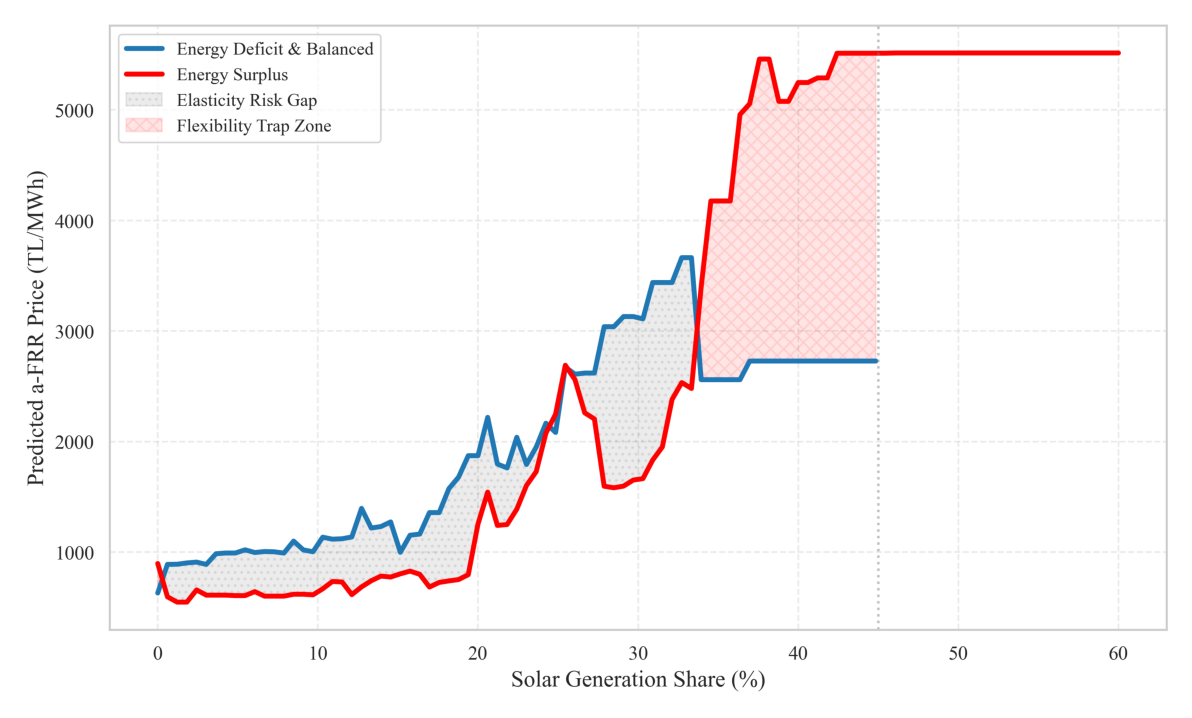

  [CACHE] Loading Appendix_I_Figure_I2_GAM_Flexibility_Stress_Botas.png and Report...


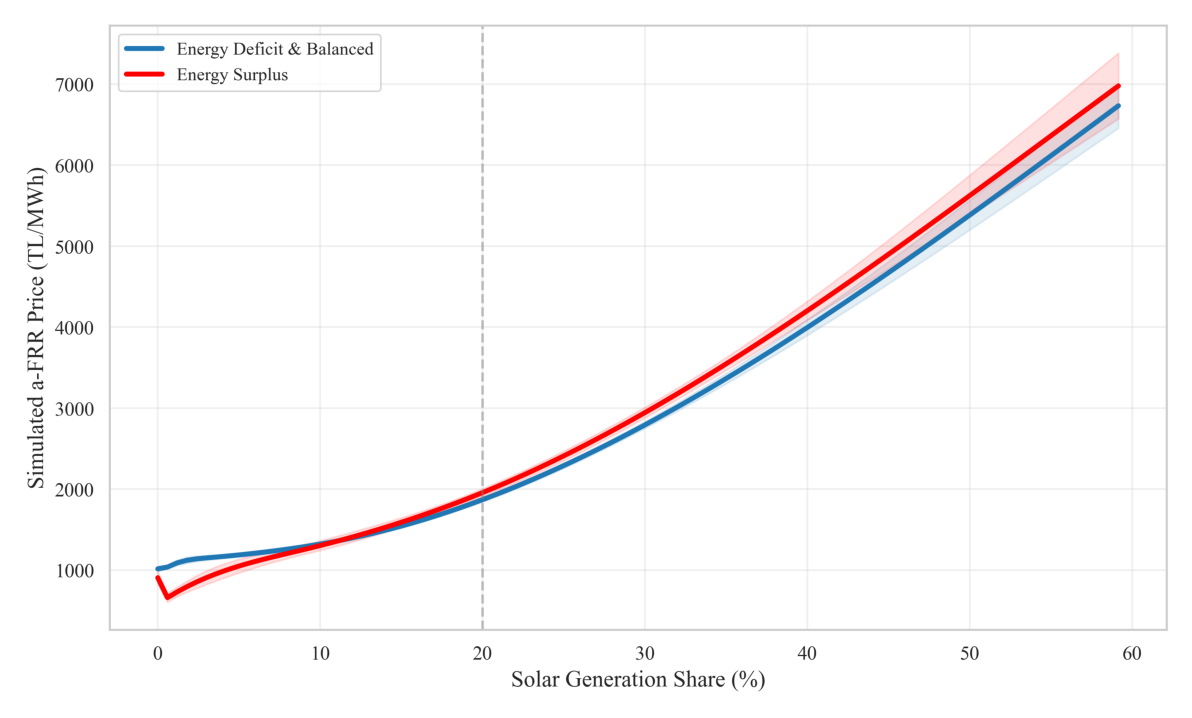

=== Appendix I: GAM Flexibility-Stress (Botaş Controlled) ===
Deficit/Balanced R²: 0.3993
Surplus R²: 0.5810


>> Appendix I (Botaş) complete.


In [15]:
# =============================================================================
# PHASE 10 — APPENDIX I: ROBUSTNESS CHECK WITH NATURAL GAS COST CONTROL (BOTAŞ)
# =============================================================================
# Produces: Appendix I — Figure I.1 (Flexibility Trap + Botaş), Figure I.2 (GAM Flexibility-Stress + Botaş)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import statsmodels.formula.api as smf
from patsy import cr
import os
import warnings

warnings.filterwarnings("ignore")

OUTPUT_DIR_P10 = os.path.join(RESULTS_BASE, "Phase_10")
os.makedirs(OUTPUT_DIR_P10, exist_ok=True)

# Orijinal akademik stile en yakın ayarlar
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

def run_appendix_i_botas(df_b):
    print(f"\n>> PHASE 10 — APPENDIX I: Botaş Robustness Check (Directory: '{OUTPUT_DIR_P10}')...")
    print("="*80)

    if 'Botas_Tariff' not in df_b.columns:
        print("!! WARNING: 'Botas_Tariff' column not found in dataset. Skipping Appendix I.")
        return

    fig11_path = os.path.join(OUTPUT_DIR_P10, 'Appendix_I_Figure_I1_Flexibility_Trap_Botas.png')
    fig12_path = os.path.join(OUTPUT_DIR_P10, 'Appendix_I_Figure_I2_GAM_Flexibility_Stress_Botas.png')
    report_path = os.path.join(OUTPUT_DIR_P10, 'Appendix_I_Botas_Report.txt')

    # =========================================================================
    # 1. XGBOOST FLEXIBILITY TRAP (+ BOTAS_TARIFF)
    # =========================================================================
    if os.path.exists(fig11_path):
        print(f"  [CACHE] Loading {os.path.basename(fig11_path)}...")
        plt.figure(figsize=(10, 6))
        plt.imshow(plt.imread(fig11_path))
        plt.axis('off')
        plt.show()
    else:
        print("  [Fig 11] Training XGBoost with Botaş Tariff...")
        dm = df_b.copy()
        if dm['Solar_Generation_Share'].max() <= 1:
            dm['Solar_Generation_Share'] *= 100

        sur = dm[dm['System_Direction_Down'] == 1]
        dfc = dm[dm['System_Direction_Down'] == 0]

        ft = ['Solar_Generation_Share','Mcp','Consumption','Wind_Generation','Hour_Sin','Hour_Cos','Botas_Tariff']

        ms = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(sur[ft], sur['a-FRR_Price'])
        md = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(dfc[ft], dfc['a-FRR_Price'])

        sr = np.linspace(0, 60, 100)
        avg = dm[ft].median()
        sim = pd.DataFrame([avg]*100, columns=ft)
        sim['Solar_Generation_Share'] = sr

        mk = sr <= 45
        yd = md.predict(sim[mk][ft])
        ys = ms.predict(sim[ft])
        ysc = ys[:len(yd)]
        sc = sr[mk]

        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.plot(sc, yd, color='#1f77b4', lw=3.0, label='Energy Deficit & Balanced')
        ax.plot(sr, ys, color='red', lw=3.0, label='Energy Surplus')
        
        ax.fill_between(sc, ysc, yd, where=(yd>=ysc), interpolate=True, color='gray', alpha=.15, hatch='...', label='Elasticity Risk Gap')
        ax.fill_between(sc, ysc, yd, where=(ysc>yd), interpolate=True, color='red', alpha=.10, hatch='xxx', label='Flexibility Trap Zone')
        
        ax.set_xlabel('Solar Generation Share (%)')
        ax.set_ylabel('Predicted a-FRR Price (TL/MWh)')
        
        ax.legend(loc='upper left', fontsize=11, frameon=True)
        ax.grid(True, ls='--', alpha=.4)
        ax.axvline(x=45, color='gray', ls=':', alpha=.5)
        
        plt.tight_layout()
        plt.savefig(fig11_path, dpi=FIG_DPI, bbox_inches='tight')
        plt.show()
        print(f"  Saved: {fig11_path}")

    # =========================================================================
    # 2. GAM FLEXIBILITY-STRESS (+ BOTAS_TARIFF)
    # =========================================================================
    if os.path.exists(fig12_path) and os.path.exists(report_path):
        print(f"  [CACHE] Loading {os.path.basename(fig12_path)} and Report...")
        plt.figure(figsize=(10, 6))
        plt.imshow(plt.imread(fig12_path))
        plt.axis('off')
        plt.show()
        
        with open(report_path, "r", encoding="utf-8") as f:
            print(f.read())
    else:
        print("\n  [Fig 12] Training GAM Flexibility-Stress with Botaş Tariff...")
        
        du = df_b[df_b['System_Direction_Down'] == 0]
        dd = df_b[df_b['System_Direction_Down'] == 1]

        formula = 'Q("a-FRR_Price") ~ cr(Solar_Generation_Share,df=6)+Consumption+Wind_Generation+Import_Coal_Generation+Botas_Tariff'

        mu = smf.ols(formula, data=du).fit()
        md = smf.ols(formula, data=dd).fit()

        sg = np.linspace(df_b['Solar_Generation_Share'].min(), df_b['Solar_Generation_Share'].max(), 100)
        pred_df = pd.DataFrame({
            'Solar_Generation_Share': sg,
            'Consumption': df_b['Consumption'].mean(),
            'Wind_Generation': df_b['Wind_Generation'].mean(),
            'Import_Coal_Generation': df_b['Import_Coal_Generation'].mean(),
            'Botas_Tariff': df_b['Botas_Tariff'].mean()
        })

        ru = mu.get_prediction(pred_df).summary_frame(alpha=.05)
        rd = md.get_prediction(pred_df).summary_frame(alpha=.05)
        
        # Yalnızca x-ekseni (çizim) için % ile çarpıyoruz
        sp = sg * 100

        fig, ax = plt.subplots(figsize=(10, 6))
        
        
        ax.plot(sp, ru['mean'], color='#1f77b4', lw=3.0, label='Energy Deficit & Balanced')
        ax.fill_between(sp, ru['mean_ci_lower'], ru['mean_ci_upper'], color='#1f77b4', alpha=.12)
        ax.plot(sp, rd['mean'], color='red', lw=3.0, label='Energy Surplus')
        ax.fill_between(sp, rd['mean_ci_lower'], rd['mean_ci_upper'], color='red', alpha=.12)
        
        ax.set_xlabel('Solar Generation Share (%)')
        ax.set_ylabel('Simulated a-FRR Price (TL/MWh)')
        
        ax.axvline(x=20, color='grey', ls='--', alpha=.5)
        ax.legend(loc='upper left', fontsize=11, frameon=True)
        ax.grid(True, alpha=.3)
        
        plt.tight_layout()
        plt.savefig(fig12_path, dpi=FIG_DPI, bbox_inches='tight')
        plt.show()
        print(f"  Saved: {fig12_path}")

        # Save and Print R² Report
        report_content = f"=== Appendix I: GAM Flexibility-Stress (Botaş Controlled) ===\n" \
                         f"Deficit/Balanced R²: {mu.rsquared:.4f}\n" \
                         f"Surplus R²: {md.rsquared:.4f}\n"
                         
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report_content)
        print(f"\n{report_content}")
        print(f"  Report Saved: {report_path}")

    print("\n>> Appendix I (Botaş) complete.")
    print("="*80)

# === MAIN EXECUTION ===
if __name__ == "__main__":
    target_df = globals().get('df', locals().get('df'))
    
    if target_df is not None and 'Botas_Tariff' in target_df.columns:
        run_appendix_i_botas(target_df)
    else:
        botas_data_path = os.path.join(DATA_DIR, 'Model_Data.xlsx')
        print(f">> Loading extended dataset from {botas_data_path}...")
        try:
            df_botas = pd.read_excel(botas_data_path)
            if 'Date_Hour' in df_botas.columns:
                df_botas['Date_Hour'] = pd.to_datetime(df_botas['Date_Hour'])
                df_botas.set_index('Date_Hour', inplace=True)
                df_botas.sort_index(inplace=True)
            run_appendix_i_botas(df_botas)
        except Exception as e:
            print(f"!! FATAL ERROR: {e}")

## Phase 11: Inflation-Robustness Checks (Ratio & Cap-Normalised FE-OLS)

Verifies that the MCP / a-FRR divergence is not an artefact of inflation or currency
drift (manuscript Section 4.6.3). Estimates fixed-effects OLS models
(Hour + Month + Year FE, standard errors clustered by day) for:
the a-FRR/MCP normalisation ratio and cap-normalised MCP & a-FRR prices.

Produces: `Inflation_Robustness_Results.csv` in `results/Phase_11_Inflation/`.

In [16]:
# =============================================================================
# PHASE 11: INFLATION-ROBUSTNESS CHECKS (RATIO & CAP-NORMALISED FE-OLS) - CACHED
# =============================================================================
import pandas as pd, numpy as np, os, warnings
import statsmodels.formula.api as smf
warnings.filterwarnings("ignore")

OUTPUT_DIR_P11 = os.path.join(RESULTS_BASE, "Phase_11_Inflation")
os.makedirs(OUTPUT_DIR_P11, exist_ok=True)

def generate_inflation_robustness(df: pd.DataFrame):
    print("\n>>> PHASE 11: INFLATION-ROBUSTNESS (RATIO & CAP-NORMALISED FE-OLS)")
    path = os.path.join(OUTPUT_DIR_P11, "Inflation_Robustness_Results.csv")
    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False)); return

    d = df.copy()
    # statsmodels formulas cannot contain hyphens -> rename
    d = d.rename(columns={'a-FRR_Price': 'aFRR',
                          'a-FRR_Price_Divide_Price_Cap': 'aFRR_over_Cap',
                          'Mcp_Divide_Price_Cap': 'Mcp_over_Cap'})
    d['Date'] = pd.to_datetime(d['Date']); d['Year'] = d['Date'].dt.year

    # inflation-neutral ratio (drop MCP<1 to avoid blow-up; winsorise 1/99)
    d_ratio = d[d['Mcp'] >= 1].copy()
    d_ratio['Ratio'] = d_ratio['aFRR'] / d_ratio['Mcp']
    lo, hi = d_ratio['Ratio'].quantile([.01, .99]); d_ratio['Ratio'] = d_ratio['Ratio'].clip(lo, hi)

    CTRL = ("Consumption + Wind_Generation_Share + Hydroelectric_Generation_Share "
            "+ Botas_Tariff + Weekend + Public_Holiday + C(Hour) + C(Month) + C(Year)")

    def fe_ols(dep, data, label):
        m = smf.ols(f"{dep} ~ Solar_Generation_Share + {CTRL}", data=data)\
               .fit(cov_type='cluster', cov_kwds={'groups': data['Date']})
        b = m.params['Solar_Generation_Share']
        return {"Dependent Variable": label,
                "Solar Coef (per unit share)": round(b, 4),
                "Effect per +1pp": round(b/100, 4),
                "Std. Error": round(m.bse['Solar_Generation_Share'], 4),
                "P-Value": round(m.pvalues['Solar_Generation_Share'], 4),
                "R-squared": round(m.rsquared, 3),
                "N": int(m.nobs)}
    try:
        rows = [
            fe_ols("Mcp",           d,       "MCP (level)"),        # merit-order, reference
            fe_ols("aFRR",          d,       "a-FRR (level)"),      # balancing, reference
            fe_ols("Ratio",         d_ratio, "a-FRR / MCP ratio"),  # inflation-neutral
            fe_ols("Mcp_over_Cap",  d,       "MCP / Price Cap"),    # inflation-neutral
            fe_ols("aFRR_over_Cap", d,       "a-FRR / Price Cap"),  # inflation-neutral
        ]
        out = pd.DataFrame(rows)
        out.to_csv(path, index=False)
        print(out.to_string(index=False))
        print("\n  Note: Hour+Month+Year fixed effects; std. errors clustered by day.")
        print(f"  Ratio model drops {len(d)-len(d_ratio)} hours with MCP<1 and winsorises at 1/99 pct.")
        print(f"  Saved: {path}")
    except Exception as e:
        print(f"  !! Error in inflation-robustness checks: {e}")

# === MAIN EXECUTION ===
if __name__ == "__main__":
    target_df = locals().get('df', globals().get('df'))
    if target_df is not None:
        generate_inflation_robustness(target_df)
    else:
        print("!! ERROR: DataFrame 'df' not found. Please run Phase 1.")


>>> PHASE 11: INFLATION-ROBUSTNESS (RATIO & CAP-NORMALISED FE-OLS)
  [CACHE] Loaded from ..\results\Phase_11_Inflation\Inflation_Robustness_Results.csv
Dependent Variable  Solar Coef (per unit share)  Effect per +1pp  Std. Error  P-Value  R-squared     N
       MCP (level)                   -6955.1624         -69.5516     63.0299      0.0      0.798 35064
     a-FRR (level)                   10686.3211         106.8632    181.0370      0.0      0.575 35064
 a-FRR / MCP ratio                      38.3336           0.3833      1.3155      0.0      0.305 34995
   MCP / Price Cap                      -1.9611          -0.0196      0.0187      0.0      0.700 35064
 a-FRR / Price Cap                       3.4121           0.0341      0.0579      0.0      0.560 35064


In [17]:
# =============================================================================
# SUPPLEMENTARY: XGBOOST PERFORMANCE METRICS (R² AND ACCURACY) - CACHED
# =============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, accuracy_score
import os
import warnings

warnings.filterwarnings("ignore")

OUTPUT_DIR_SUPP = os.path.join(RESULTS_BASE, "Supplementary_Metrics")
os.makedirs(OUTPUT_DIR_SUPP, exist_ok=True)

def run_xgboost_performance_metrics():
    print(">> Computing XGBoost performance metrics...")
    path = os.path.join(OUTPUT_DIR_SUPP, "XGBoost_Performance_Metrics.csv")

    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False))
        return

    # 1. Load data
    df_ml = None
    try:
        df_ml = pd.read_excel(DATA_FILE)
        print(f">> '{DATA_FILE}' loaded successfully.")
    except Exception:
        if 'df' in globals() and globals()['df'] is not None:
            df_ml = globals()['df'].copy()
            print(">> Using in-memory 'df'.")
        else:
            print("ERROR: Dataset not found. Ensure the data file exists or run Phase 1.")
            return

    # 2. Data preparation
    if df_ml['Solar_Generation_Share'].max() <= 1.0:
        df_ml['Solar_Generation_Share'] *= 100

    features_core = ['Solar_Generation_Share', 'Consumption', 'Wind_Generation', 'Price_Cap', 'Hour_Sin', 'Hour_Cos']
    features_with_mcp = features_core + ['Mcp']
    # Phase 6.2 (Flexibility Trap) ile birebir aynı set — rejim modelleri bu setle ölçülmeli
    features_trap = ['Solar_Generation_Share', 'Mcp', 'Consumption', 'Wind_Generation', 'Hour_Sin', 'Hour_Cos']

    # 3. General models (Phase 6.1)
    print(">> Training general models...")

    m_a = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(df_ml[features_core], df_ml['Mcp'])
    m_b = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(df_ml[features_with_mcp], df_ml['a-FRR_Price'])
    m_c = xgb.XGBClassifier(n_estimators=200, random_state=42).fit(df_ml[features_core], df_ml['System_Direction_Down'])

    # 4. Regime-conditional models (Phase 6.2 - Flexibility Trap)
    print(">> Training regime-conditional models...")

    surplus_data = df_ml[df_ml['System_Direction_Down'] == 1]
    deficit_bal_data = df_ml[df_ml['System_Direction_Down'] == 0]

    model_surplus = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(surplus_data[features_trap], surplus_data['a-FRR_Price'])
    model_deficit = xgb.XGBRegressor(n_estimators=200, random_state=42).fit(deficit_bal_data[features_trap], deficit_bal_data['a-FRR_Price'])

    # 5. Metrics
    y_pred_mcp = m_a.predict(df_ml[features_core])
    r2_mcp = r2_score(df_ml['Mcp'], y_pred_mcp)

    y_pred_afrr = m_b.predict(df_ml[features_with_mcp])
    r2_afrr = r2_score(df_ml['a-FRR_Price'], y_pred_afrr)

    y_pred_dir = m_c.predict(df_ml[features_core])
    acc_dir = accuracy_score(df_ml['System_Direction_Down'], y_pred_dir)

    y_pred_def = model_deficit.predict(deficit_bal_data[features_trap])
    r2_def = r2_score(deficit_bal_data['a-FRR_Price'], y_pred_def)

    y_pred_sur = model_surplus.predict(surplus_data[features_trap])
    r2_sur = r2_score(surplus_data['a-FRR_Price'], y_pred_sur)

    # 6. Save + report
    out = pd.DataFrame([
        {"Metric": "MCP Model R2 Score",            "Value": round(r2_mcp, 3)},
        {"Metric": "a-FRR (Volatility) R2 Score",   "Value": round(r2_afrr, 3)},
        {"Metric": "System Direction Accuracy (%)", "Value": round(acc_dir * 100, 1)},
        {"Metric": "Deficit Regime Model R2",       "Value": round(r2_def, 3)},
        {"Metric": "Surplus Regime Model R2",       "Value": round(r2_sur, 3)},
    ])
    out.to_csv(path, index=False)

    print("\n" + "=" * 50)
    print("XGBOOST PERFORMANCE METRICS SUMMARY")
    print("=" * 50)
    print(f"1. MCP Model R2 Score:             {r2_mcp:.3f}")
    print(f"2. a-FRR (Volatility) R2 Score:    {r2_afrr:.3f}")
    print(f"3. System Direction Accuracy:      {acc_dir*100:.1f}%")
    print(f"4. Deficit Regime Model R2:        {r2_def:.3f}")
    print(f"5. Surplus Regime Model R2:        {r2_sur:.3f}")
    print("=" * 50)
    print(f"  Saved: {path}")

# === MAIN EXECUTION ===
if __name__ == "__main__":
    run_xgboost_performance_metrics()

>> Computing XGBoost performance metrics...
  [CACHE] Loaded from ..\results\Supplementary_Metrics\XGBoost_Performance_Metrics.csv
                       Metric  Value
           MCP Model R2 Score  0.932
  a-FRR (Volatility) R2 Score  0.910
System Direction Accuracy (%) 86.000
      Deficit Regime Model R2  0.900
      Surplus Regime Model R2  0.970


In [18]:
# =============================================================================
# SUPPLEMENTARY: GAM PERFORMANCE METRICS (R²) - CACHED
# =============================================================================

import pandas as pd
import os
import statsmodels.formula.api as smf
from patsy import cr

OUTPUT_DIR_SUPP = os.path.join(RESULTS_BASE, "Supplementary_Metrics")
os.makedirs(OUTPUT_DIR_SUPP, exist_ok=True)

def check_gam_performance(df):
    print("\n>> Computing GAM model R-squared values...")
    print("-" * 50)
    path = os.path.join(OUTPUT_DIR_SUPP, "GAM_Performance_Metrics.csv")

    if os.path.exists(path):
        print(f"  [CACHE] Loaded from {path}")
        print(pd.read_csv(path).to_string(index=False))
        print("-" * 50)
        return

    # Regime separation
    df_up = df[df['System_Direction_Down'] == 0].copy()
    df_down = df[df['System_Direction_Down'] == 1].copy()

    # Same formula as Phase 8
    formula = 'Q("a-FRR_Price") ~ cr(Solar_Generation_Share, df=6) + Consumption + Wind_Generation + Import_Coal_Generation'

    m_up = smf.ols(formula, data=df_up).fit()
    m_down = smf.ols(formula, data=df_down).fit()

    out = pd.DataFrame([
        {"Model": "Energy DEFICIT (Up-Regulation)",   "R-squared": round(m_up.rsquared, 4),   "N": int(m_up.nobs)},
        {"Model": "Energy SURPLUS (Down-Regulation)", "R-squared": round(m_down.rsquared, 4), "N": int(m_down.nobs)},
    ])
    out.to_csv(path, index=False)

    print(f"1. Energy DEFICIT Model (Up-Regulation) R-squared: {m_up.rsquared:.4f}")
    print(f"2. Energy SURPLUS Model (Down-Regulation) R-squared: {m_down.rsquared:.4f}")
    print(f"  Saved: {path}")
    print("-" * 50)

# === MAIN EXECUTION ===
if __name__ == "__main__":
    target_df = locals().get('df', globals().get('df'))
    if target_df is not None:
        check_gam_performance(target_df)
    else:
        print("!! ERROR: DataFrame 'df' not found. Please run Phase 1.")


>> Computing GAM model R-squared values...
--------------------------------------------------
  [CACHE] Loaded from ..\results\Supplementary_Metrics\GAM_Performance_Metrics.csv
                           Model  R-squared     N
  Energy DEFICIT (Up-Regulation)     0.3530 25902
Energy SURPLUS (Down-Regulation)     0.5618  9162
--------------------------------------------------


## Submission Figures — dergi numaralandırmasıyla dışa aktarma

Aşağıdaki hücre, makaledeki figür numaralarına göre 10 PNG'yi `results/Submission_Figures/` klasörüne kopyalar
(`Figure_1a.png` … `Figure_9.png`) ve her biri için piksel boyutu, dpi etiketi ve 19 cm çift-sütun baskıdaki
etkin çözünürlüğü raporlar. Editorial Manager'a **bu klasördeki dosyalar** yüklenir.


In [19]:
# =============================================================================
# SUBMISSION FIGURES: MANUSCRIPT-NUMBERED EXPORT (Figure_1a ... Figure_9)
# =============================================================================
import glob, shutil
from PIL import Image

SUBMISSION_DIR = os.path.join(RESULTS_BASE, "Submission_Figures")
os.makedirs(SUBMISSION_DIR, exist_ok=True)

# (hedef ad, kaynak desen) -- makale numarasi <- pipeline dosyasi
_submission_map = [
    ("Figure_1a", os.path.join("Phase_5", "Phase_5_Figure_1_*.png")),
    ("Figure_1b", os.path.join("Phase_5", "Phase_5_Figure_2_*.png")),
    ("Figure_2",  os.path.join("Phase_9", "Figure_3_*.png")),
    ("Figure_3",  os.path.join("Phase_5", "Phase_5_Figure_4_*.png")),
    ("Figure_4",  os.path.join("Phase_6", "Phase_6_Figure_5_*.png")),
    ("Figure_5",  os.path.join("Phase_5", "Phase_5_Figure_6_*.png")),
    ("Figure_6",  os.path.join("Phase_6", "Phase_6_Figure_7_*.png")),
    ("Figure_7",  os.path.join("Phase_6", "Phase_6_Figure_8_*.png")),
    ("Figure_8",  os.path.join("Phase_6", "Phase_6_Figure_9_*.png")),
    ("Figure_9",  os.path.join("Phase_8", "Phase_8_Figure_10_GAM_Flexibility_Stress.png")),
]

print(f">>> SUBMISSION FIGURES -> {SUBMISSION_DIR}\n")
_problems = []
for _target, _pattern in _submission_map:
    _hits = sorted(glob.glob(os.path.join(RESULTS_BASE, _pattern)))
    if len(_hits) != 1:
        _problems.append(f"{_target}: desen '{_pattern}' icin {len(_hits)} eslesme bulundu {_hits}")
        continue
    _dst = os.path.join(SUBMISSION_DIR, _target + ".png")
    shutil.copy2(_hits[0], _dst)
    with Image.open(_dst) as _im:
        _w, _h = _im.size
        _tag = _im.info.get("dpi", ("?", "?"))[0]
    _eff = _w / (19.0 / 2.54)   # 19 cm cift-sutun baskida etkin dpi
    print(f"  {_target:<10} {_w}x{_h}px | dpi etiketi: {_tag} | 19 cm baskida ~{_eff:.0f} dpi  <- {os.path.basename(_hits[0])}")

if _problems:
    print("\n!! SORUN:")
    for _p in _problems: print("   -", _p)
else:
    print("\n>> 10/10 figur hazir. EM'e 'results/Submission_Figures/' icindekileri yukleyin.")


>>> SUBMISSION FIGURES -> ..\results\Submission_Figures

  Figure_1a  7694x3802px | dpi etiketi: 650.0114 | 19 cm baskida ~1029 dpi  <- Phase_5_Figure_1_Daily_Market_Profile.png
  Figure_1b  7694x3802px | dpi etiketi: 650.0114 | 19 cm baskida ~1029 dpi  <- Phase_5_Figure_2_Daily_Market_Profile.png
  Figure_2   8190x11141px | dpi etiketi: 650.0114 | 19 cm baskida ~1095 dpi  <- Figure_3_Methodological_Framework_Updated.png
  Figure_3   6395x3139px | dpi etiketi: 650.0114 | 19 cm baskida ~855 dpi  <- Phase_5_Figure_4_Hourly_Merit_Order_Effect_MCP.png
  Figure_4   6392x3786px | dpi etiketi: 650.0114 | 19 cm baskida ~855 dpi  <- Phase_6_Figure_5_PDP_Merit_Order_and_Volatility.png
  Figure_5   6395x3141px | dpi etiketi: 650.0114 | 19 cm baskida ~855 dpi  <- Phase_5_Figure_6_Hourly_Volatility_Effect_aFRR.png
  Figure_6   6392x3786px | dpi etiketi: 650.0114 | 19 cm baskida ~855 dpi  <- Phase_6_Figure_7_PDP_Merit_Order_and_Volatility.png
  Figure_7   10292x3786px | dpi etiketi: 650.0114 | 19 cm

## Supplementary Figures — ek dosya figürlerinin dışa aktarımı

Supplementary Material içinde gömülü beş figürü (F.1, F.2, H1, I.1, I.2) kendi etiketleriyle
`results/Supplementary_Figures/` klasörüne kopyalar ve çözünürlük raporu basar.
**Not:** Bunlar EM'e ayrı 'Figure' kalemi olarak YÜKLENMEZ — Supplementary docx'in içinde
gömülü giderler; bu klasör docx görsellerini tazelemek ve repo bütünlüğü içindir.


In [20]:
# =============================================================================
# SUPPLEMENTARY FIGURES: LABELLED EXPORT (F1, F2, H1, I1, I2)
# =============================================================================
import shutil
from PIL import Image

SUPP_FIG_DIR = os.path.join(RESULTS_BASE, "Supplementary_Figures")
os.makedirs(SUPP_FIG_DIR, exist_ok=True)

# (hedef ad, kaynak dosya) -- supplementary etiketi <- pipeline ciktisi (tam ad, joker yok)
_supp_map = [
    ("Supplementary_Figure_F1", os.path.join("Phase_10", "Appendix_F1_MCP_Correlation.png")),
    ("Supplementary_Figure_F2", os.path.join("Phase_10", "Appendix_F2_aFRR_Correlation.png")),
    ("Supplementary_Figure_H1", os.path.join("Phase_10", "Appendix_H_Down_Regulation_Volume.png")),
    ("Supplementary_Figure_I1", os.path.join("Phase_10", "Appendix_I_Figure_I1_Flexibility_Trap_Botas.png")),
    ("Supplementary_Figure_I2", os.path.join("Phase_10", "Appendix_I_Figure_I2_GAM_Flexibility_Stress_Botas.png")),
]

print(f">>> SUPPLEMENTARY FIGURES -> {SUPP_FIG_DIR}\n")
_missing = []
for _target, _rel in _supp_map:
    _srcp = os.path.join(RESULTS_BASE, _rel)
    if not os.path.exists(_srcp):
        _missing.append(f"{_target}: kaynak yok -> {_srcp}")
        continue
    _dst = os.path.join(SUPP_FIG_DIR, _target + ".png")
    shutil.copy2(_srcp, _dst)
    with Image.open(_dst) as _im:
        _w, _h = _im.size
        _tag = _im.info.get("dpi", ("?", "?"))[0]
    print(f"  {_target:<26} {_w}x{_h}px | dpi etiketi: {_tag}  <- {os.path.basename(_srcp)}")

if _missing:
    print("\n!! SORUN:")
    for _m in _missing: print("   -", _m)
else:
    print("\n>> 5/5 supplementary figur kopyalandi.")
    print(">> Bunlar Supplementary docx icinde gomulu gider; EM'e ayri Figure kalemi olarak yuklenmez.")


>>> SUPPLEMENTARY FIGURES -> ..\results\Supplementary_Figures

  Supplementary_Figure_F1    3000x2400px | dpi etiketi: 299.9994  <- Appendix_F1_MCP_Correlation.png
  Supplementary_Figure_F2    3000x2400px | dpi etiketi: 299.9994  <- Appendix_F2_aFRR_Correlation.png
  Supplementary_Figure_H1    2953x1752px | dpi etiketi: 299.9994  <- Appendix_H_Down_Regulation_Volume.png
  Supplementary_Figure_I1    2950x1748px | dpi etiketi: 299.9994  <- Appendix_I_Figure_I1_Flexibility_Trap_Botas.png
  Supplementary_Figure_I2    2950x1748px | dpi etiketi: 299.9994  <- Appendix_I_Figure_I2_GAM_Flexibility_Stress_Botas.png

>> 5/5 supplementary figur kopyalandi.
>> Bunlar Supplementary docx icinde gomulu gider; EM'e ayri Figure kalemi olarak yuklenmez.
